<a href="https://colab.research.google.com/github/medikalshop9-cell/Attrition/blob/main/Stack_overflow_insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# AI Adoption & Switching Behaviour Analysis
# Stack Overflow Developer Survey (2016-2025)
# ============================================================
# This notebook reproduces all insights from our EDA.
# Upload master_switching_dataset.csv to Colab before running.
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style for all charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [3]:
# ============================================================
# 2. LOAD DATASET
# ============================================================
# If running in Google Colab, upload the CSV first:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('/content/drive/MyDrive/harmonize/master_switching_dataset.csv')

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Total rows (respondents): {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Year range: {df['Year'].min()} to {df['Year'].max()}")
print(f"\nRespondents per year:")
print(df['Year'].value_counts().sort_index())

DATASET OVERVIEW
Total rows (respondents): 665,785
Total columns: 36
Year range: 2016 to 2025

Respondents per year:
Year
2016    49766
2017    43743
2018    82003
2019    88680
2020    60632
2021    83417
2022    71726
2023    87945
2024    59954
2025    37919
Name: count, dtype: int64



GENERAL EDA


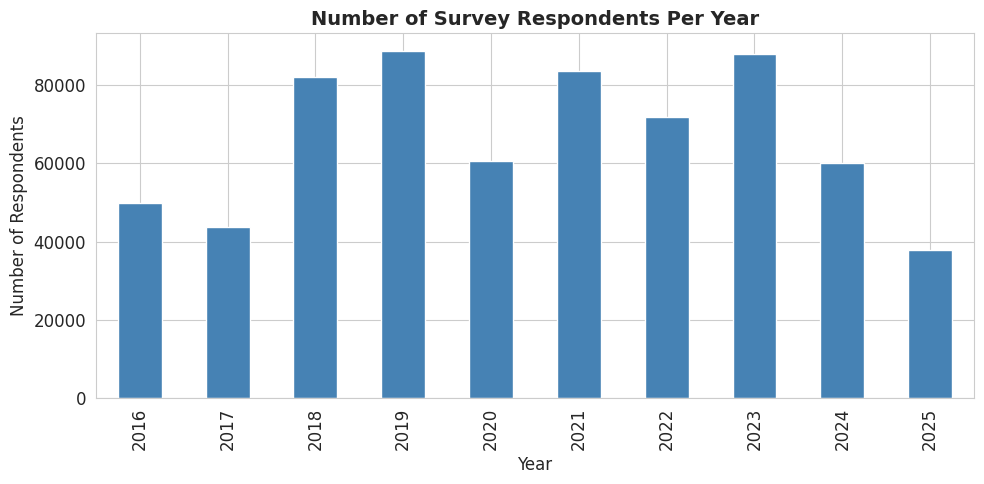


Column completeness (% non-null):
  Profile_Expertise             : 69%
  Profile_Participation         : 68%
  Profile_Risk                  : 100%
  Profile_Role                  : 89%
  Age_Group                     : 51%
  Education_Group               : 91%
  Remote_Group                  : 37%
  Salary_Group                  : 48%
  SO_High_Visit                 : 89%
  AI_Adopted                    : 27%


In [4]:
# ============================================================
# 3. GENERAL EDA: WHAT DOES THE DATA LOOK LIKE?
# ============================================================
print("\n" + "="*60)
print("GENERAL EDA")
print("="*60)

# 3a. Respondents per year (bar chart)
fig, ax = plt.subplots(figsize=(10, 5))
df['Year'].value_counts().sort_index().plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Number of Survey Respondents Per Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Respondents')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

# 3b. Column completeness (how much data do we have for each variable?)
print("\nColumn completeness (% non-null):")
key_cols = ['Profile_Expertise', 'Profile_Participation', 'Profile_Risk',
            'Profile_Role', 'Age_Group', 'Education_Group', 'Remote_Group',
            'Salary_Group', 'SO_High_Visit', 'AI_Adopted']
for col in key_cols:
    if col in df.columns:
        pct = df[col].notna().mean() * 100
        print(f"  {col:<30s}: {pct:.0f}%")



AGE vs AI ADOPTION (2023-2025)


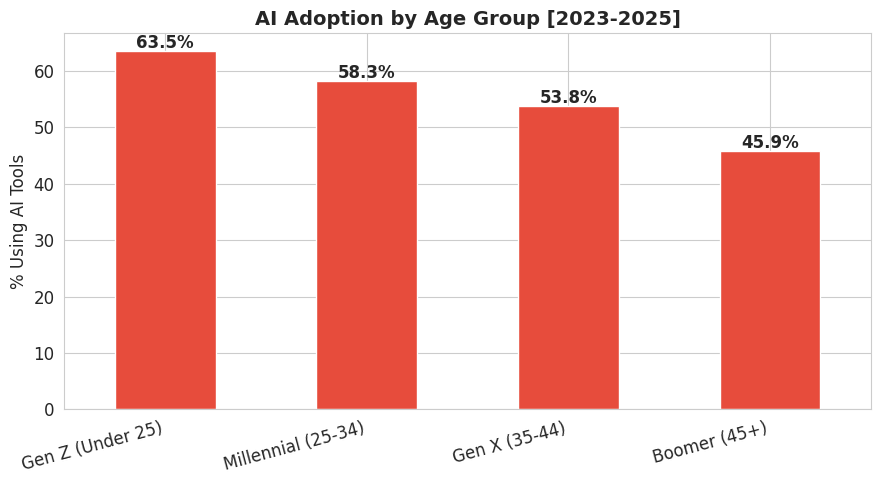

Insight: AI adoption is a perfect staircase. The younger you are,
the more you use AI. Gen Z adopts at ~1.5x the rate of Boomers.


In [5]:
# ============================================================
# 4. AGE vs AI ADOPTION
# ============================================================
# We check: do younger developers adopt AI more than older ones?
print("\n" + "="*60)
print("AGE vs AI ADOPTION (2023-2025)")
print("="*60)

df_ai = df[df['Year'] >= 2023].copy()

if 'Age_Group' in df.columns:
    age_order = ['Gen Z (Under 25)', 'Millennial (25-34)', 'Gen X (35-44)', 'Boomer (45+)']
    age_ai = df_ai.groupby('Age_Group')['AI_Adopted'].mean().reindex(age_order) * 100

    fig, ax = plt.subplots(figsize=(9, 5))
    age_ai.plot(kind='bar', color='#e74c3c', ax=ax)
    ax.set_title('AI Adoption by Age Group [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Using AI Tools')
    ax.set_xlabel('')
    ax.set_xticklabels(age_order, rotation=15, ha='right')
    for i, v in enumerate(age_ai.values):
        if not np.isnan(v):
            ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Insight: AI adoption is a perfect staircase. The younger you are,")
    print("the more you use AI. Gen Z adopts at ~1.5x the rate of Boomers.")


SALARY vs AI ADOPTION (2023-2025)


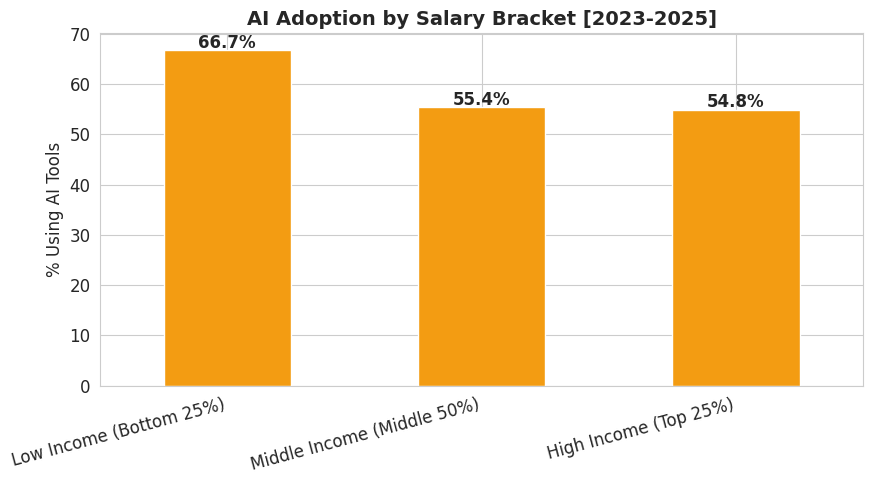

Insight: Low-income developers use AI the most. AI is an equalizer,
helping lower-paid developers punch above their weight.


In [6]:
# ============================================================
# 5. SALARY vs AI ADOPTION
# ============================================================
# We check: do lower-income developers use AI more?
print("\n" + "="*60)
print("SALARY vs AI ADOPTION (2023-2025)")
print("="*60)

if 'Salary_Group' in df.columns:
    sal_order = ['Low Income (Bottom 25%)', 'Middle Income (Middle 50%)', 'High Income (Top 25%)']
    sal_ai = df_ai.groupby('Salary_Group')['AI_Adopted'].mean().reindex(sal_order) * 100

    fig, ax = plt.subplots(figsize=(9, 5))
    sal_ai.plot(kind='bar', color='#f39c12', ax=ax)
    ax.set_title('AI Adoption by Salary Bracket [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Using AI Tools')
    ax.set_xlabel('')
    ax.set_xticklabels(sal_order, rotation=15, ha='right')
    for i, v in enumerate(sal_ai.values):
        if not np.isnan(v):
            ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Insight: Low-income developers use AI the most. AI is an equalizer,")
    print("helping lower-paid developers punch above their weight.")


EDUCATION vs AI ADOPTION (2023-2025)


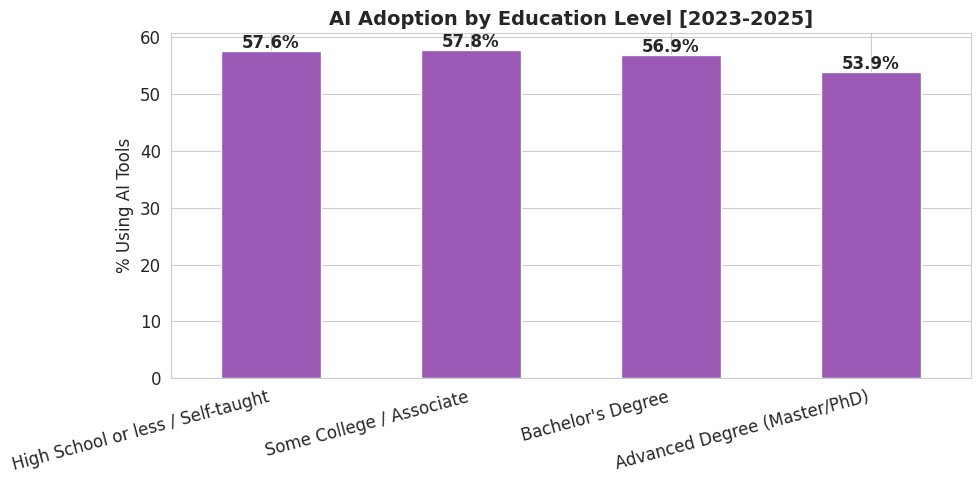

Insight: Self-taught developers use AI more than PhDs.
AI acts as a tutor for people without formal training.


In [7]:
# ============================================================
# 6. EDUCATION vs AI ADOPTION
# ============================================================
# We check: do self-taught developers lean on AI more than PhDs?
print("\n" + "="*60)
print("EDUCATION vs AI ADOPTION (2023-2025)")
print("="*60)

if 'Education_Group' in df.columns:
    ed_order = ['High School or less / Self-taught', 'Some College / Associate',
                "Bachelor's Degree", 'Advanced Degree (Master/PhD)']
    ed_ai = df_ai.groupby('Education_Group')['AI_Adopted'].mean().reindex(ed_order) * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    ed_ai.plot(kind='bar', color='#9b59b6', ax=ax)
    ax.set_title('AI Adoption by Education Level [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Using AI Tools')
    ax.set_xlabel('')
    ax.set_xticklabels(ed_order, rotation=15, ha='right')
    for i, v in enumerate(ed_ai.values):
        if not np.isnan(v):
            ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Insight: Self-taught developers use AI more than PhDs.")
    print("AI acts as a tutor for people without formal training.")


REMOTE WORK vs AI ADOPTION (2023-2025)


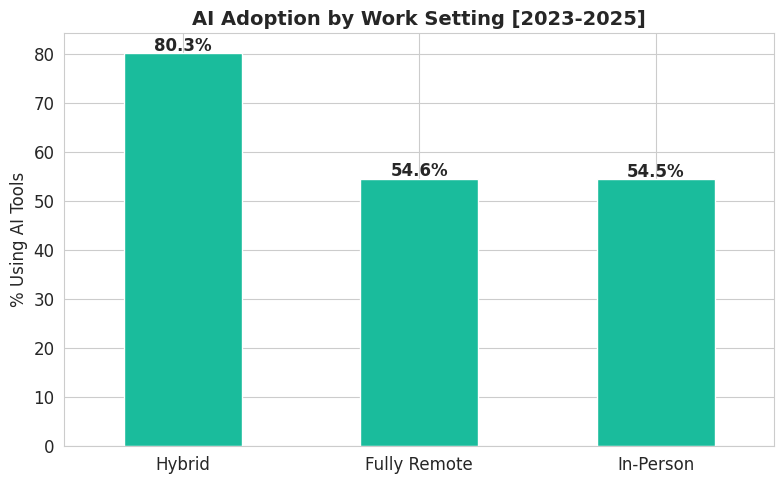

Insight: Hybrid workers use AI the most. In-person workers use it least,
possibly due to corporate bans or having colleagues to ask instead.


In [8]:
# ============================================================
# 7. REMOTE WORK vs AI ADOPTION
# ============================================================
# We check: do remote workers use AI more because they can't ask a coworker?
print("\n" + "="*60)
print("REMOTE WORK vs AI ADOPTION (2023-2025)")
print("="*60)

if 'Remote_Group' in df.columns:
    remote_order = ['Hybrid', 'Fully Remote', 'In-Person']
    remote_ai = df_ai.groupby('Remote_Group')['AI_Adopted'].mean().reindex(remote_order) * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    remote_ai.plot(kind='bar', color='#1abc9c', ax=ax)
    ax.set_title('AI Adoption by Work Setting [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Using AI Tools')
    ax.set_xlabel('')
    ax.set_xticklabels(remote_order, rotation=0)
    for i, v in enumerate(remote_ai.values):
        if not np.isnan(v):
            ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Insight: Hybrid workers use AI the most. In-person workers use it least,")
    print("possibly due to corporate bans or having colleagues to ask instead.")


EXPERTISE: STACK OVERFLOW ABANDONMENT OVER TIME


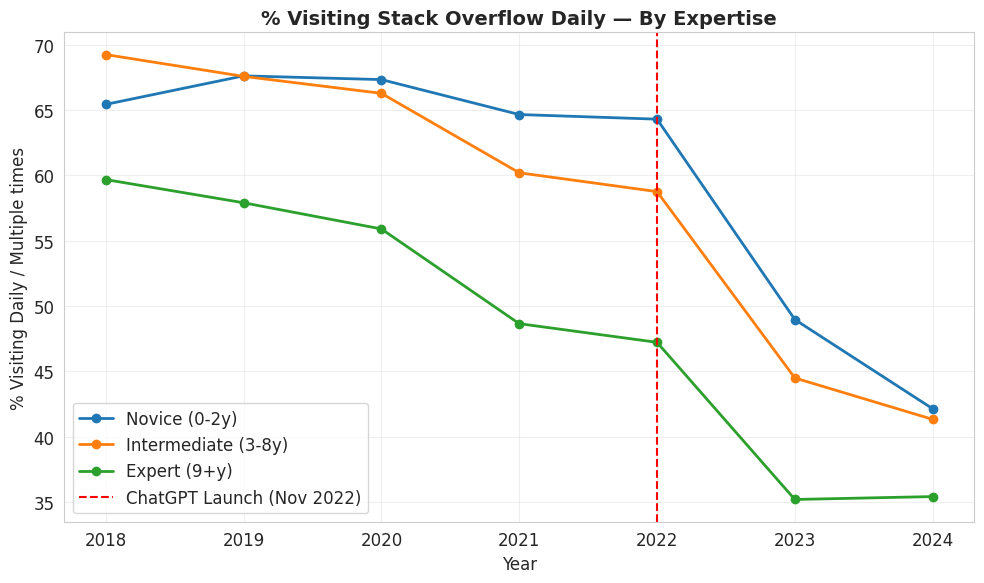


Exact data per year:
  2018 (n=67,591): Novice (0-2y): 65.4% | Intermediate (3-8y): 69.2% | Expert (9+y): 59.7%
  2019 (n=74,072): Novice (0-2y): 67.6% | Intermediate (3-8y): 67.6% | Expert (9+y): 57.9%
  2020 (n=43,044): Novice (0-2y): 67.3% | Intermediate (3-8y): 66.3% | Expert (9+y): 55.9%
  2021 (n=60,864): Novice (0-2y): 64.6% | Intermediate (3-8y): 60.2% | Expert (9+y): 48.7%
  2022 (n=51,532): Novice (0-2y): 64.3% | Intermediate (3-8y): 58.8% | Expert (9+y): 47.2%
  2023 (n=65,782): Novice (0-2y): 49.0% | Intermediate (3-8y): 44.5% | Expert (9+y): 35.2%
  2024 (n=49,815): Novice (0-2y): 42.1% | Intermediate (3-8y): 41.3% | Expert (9+y): 35.4%

Insight: Novices abandoned Stack Overflow the fastest after ChatGPT.
Experts held on longer because they deal with complex, high-risk problems.


In [9]:
# ============================================================
# 8. EXPERTISE PROFILE: Stack Overflow Abandonment Over Time
# ============================================================
# We check: did Novices abandon Stack Overflow faster than Experts?
print("\n" + "="*60)
print("EXPERTISE: STACK OVERFLOW ABANDONMENT OVER TIME")
print("="*60)

if 'Profile_Expertise' in df.columns:
    df_exp = df.dropna(subset=['Profile_Expertise', 'SO_High_Visit'])
    visit_by_exp = df_exp.groupby(['Year', 'Profile_Expertise'])['SO_High_Visit'].mean().unstack() * 100

    exp_order = ['Novice (0-2y)', 'Intermediate (3-8y)', 'Expert (9+y)']
    fig, ax = plt.subplots(figsize=(10, 6))
    for col in exp_order:
        if col in visit_by_exp.columns:
            data = visit_by_exp[col].dropna()
            ax.plot(data.index, data.values, marker='o', linewidth=2, label=col)

    ax.axvline(x=2022, color='red', linestyle='--', linewidth=1.5, label='ChatGPT Launch (Nov 2022)')
    ax.set_title('% Visiting Stack Overflow Daily — By Expertise', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Visiting Daily / Multiple times')
    ax.set_xlabel('Year')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print exact numbers
    print("\nExact data per year:")
    for year in sorted(visit_by_exp.index):
        parts = [f"{col}: {visit_by_exp.loc[year, col]:.1f}%" for col in exp_order
                 if col in visit_by_exp.columns and not pd.isna(visit_by_exp.loc[year, col])]
        if parts:
            n = len(df_exp[df_exp['Year'] == year])
            print(f"  {year} (n={n:,}): " + " | ".join(parts))

    print("\nInsight: Novices abandoned Stack Overflow the fastest after ChatGPT.")
    print("Experts held on longer because they deal with complex, high-risk problems.")



PARTICIPATION (99-9-1 RULE): AI ADOPTION


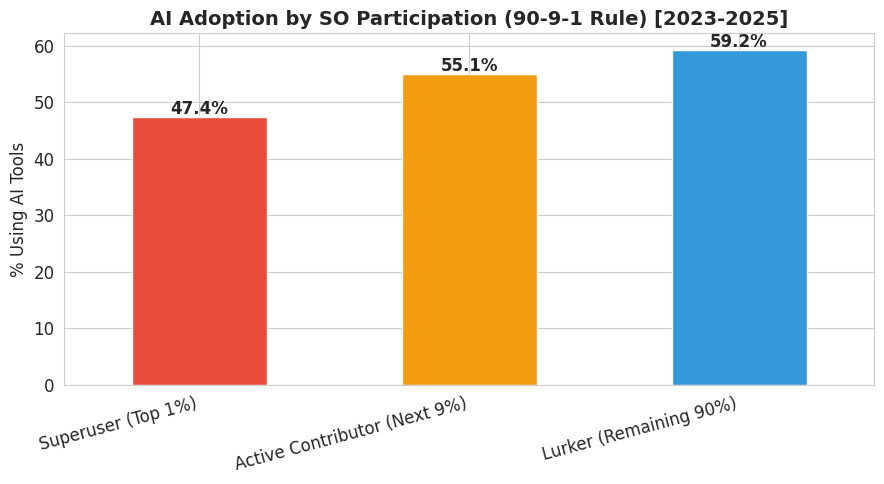

Total valid responses: 141,857

Insight: Lurkers (the 90%) adopt AI the most.
Superusers (the top 1% who answer questions) resist AI the most.
Borrowed theory from Martin Quinn to group participation


In [10]:
# ============================================================
# 9. PARTICIPATION PROFILE (99-9-1 Rule): AI Adoption
# ============================================================
# We check: do Lurkers adopt AI more than Superusers?
print("\n" + "="*60)
print("PARTICIPATION (99-9-1 RULE): AI ADOPTION")
print("="*60)

if 'Profile_Participation' in df.columns:
    part_order = ['Superuser (Top 1%)', 'Active Contributor (Next 9%)', 'Lurker (Remaining 90%)']
    df_part_ai = df_ai.dropna(subset=['Profile_Participation', 'AI_Adopted'])
    part_ai = df_part_ai.groupby('Profile_Participation')['AI_Adopted'].mean().reindex(part_order) * 100

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#e74c3c', '#f39c12', '#3498db']
    part_ai.plot(kind='bar', color=colors, ax=ax)
    ax.set_title('AI Adoption by SO Participation (90-9-1 Rule) [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Using AI Tools')
    ax.set_xlabel('')
    ax.set_xticklabels(part_order, rotation=15, ha='right')
    for i, v in enumerate(part_ai.values):
        if not np.isnan(v):
            ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Total valid responses: {len(df_part_ai):,}")
    print("\nInsight: Lurkers (the 90%) adopt AI the most.")
    print("Superusers (the top 1% who answer questions) resist AI the most.")
    print("Borrowed theory from Martin Quinn to group participation")


RISK PROFILE: STACK OVERFLOW ABANDONMENT (DiD VIEW)


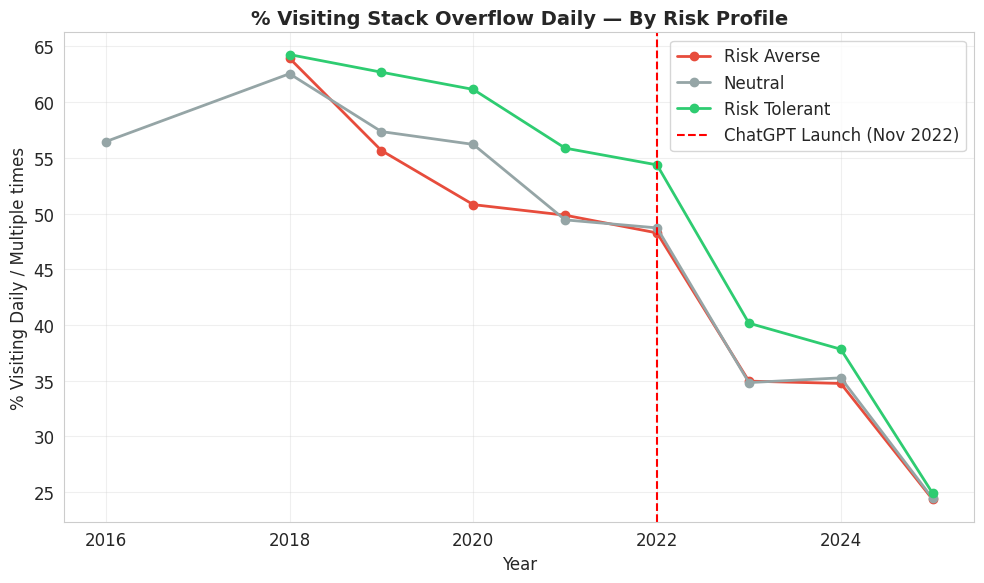


Exact data per year:
  2016 (n=46,153): Neutral: 56.5%
  2018 (n=73,767): Risk Averse: 63.9% | Neutral: 62.6% | Risk Tolerant: 64.3%
  2019 (n=88,252): Risk Averse: 55.7% | Neutral: 57.4% | Risk Tolerant: 62.7%
  2020 (n=55,496): Risk Averse: 50.8% | Neutral: 56.2% | Risk Tolerant: 61.1%
  2021 (n=82,413): Risk Averse: 49.9% | Neutral: 49.4% | Risk Tolerant: 55.9%
  2022 (n=70,952): Risk Averse: 48.3% | Neutral: 48.7% | Risk Tolerant: 54.4%
  2023 (n=87,134): Risk Averse: 35.0% | Neutral: 34.8% | Risk Tolerant: 40.2%
  2024 (n=58,335): Risk Averse: 34.8% | Neutral: 35.3% | Risk Tolerant: 37.8%
  2025 (n=32,668): Risk Averse: 24.3% | Neutral: 24.4% | Risk Tolerant: 24.9%

Insight: Risk-Tolerant developers were the HEAVIEST SO users before ChatGPT.
After ChatGPT, they abandoned SO faster than Risk-Averse developers.
The gap between the two groups narrowed — the treatment effect of ChatGPT.


In [11]:
# ============================================================
# 10. RISK PROFILE: Stack Overflow Abandonment (DiD View)
# ============================================================
# We check: did Risk-Tolerant developers drop Stack Overflow faster?
print("\n" + "="*60)
print("RISK PROFILE: STACK OVERFLOW ABANDONMENT (DiD VIEW)")
print("="*60)

if 'Profile_Risk' in df.columns:
    df_risk = df.dropna(subset=['SO_High_Visit'])
    visit_by_risk = df_risk.groupby(['Year', 'Profile_Risk'])['SO_High_Visit'].mean().unstack() * 100

    risk_order = ['Risk Averse', 'Neutral', 'Risk Tolerant']
    fig, ax = plt.subplots(figsize=(10, 6))
    risk_colors = {'Risk Averse': '#e74c3c', 'Neutral': '#95a5a6', 'Risk Tolerant': '#2ecc71'}
    for col in risk_order:
        if col in visit_by_risk.columns:
            data = visit_by_risk[col].dropna()
            ax.plot(data.index, data.values, marker='o', linewidth=2, label=col, color=risk_colors[col])

    ax.axvline(x=2022, color='red', linestyle='--', linewidth=1.5, label='ChatGPT Launch (Nov 2022)')
    ax.set_title('% Visiting Stack Overflow Daily — By Risk Profile', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Visiting Daily / Multiple times')
    ax.set_xlabel('Year')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nExact data per year:")
    for year in sorted(visit_by_risk.index):
        parts = [f"{col}: {visit_by_risk.loc[year, col]:.1f}%" for col in risk_order
                 if col in visit_by_risk.columns and not pd.isna(visit_by_risk.loc[year, col])]
        if parts:
            n = len(df_risk[df_risk['Year'] == year])
            print(f"  {year} (n={n:,}): " + " | ".join(parts))

    print("\nInsight: Risk-Tolerant developers were the HEAVIEST SO users before ChatGPT.")
    print("After ChatGPT, they abandoned SO faster than Risk-Averse developers.")
    print("The gap between the two groups narrowed — the treatment effect of ChatGPT.")



RISK PROFILE: AI ADOPTION


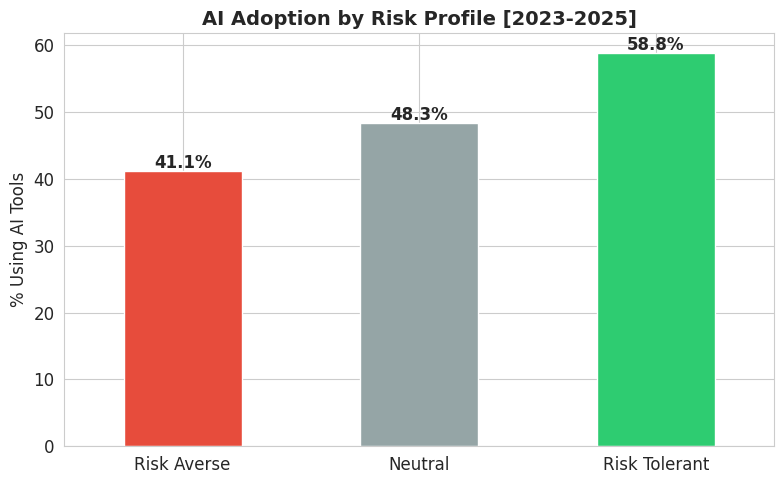

Insight: Risk-Tolerant developers adopt AI at 58.8%.
Risk-Averse developers only adopt at 41.1%. A massive 17.7% gap.
This can even be explain using the DOI by Roger's Theory of diffusion


In [12]:
# ============================================================
# 11. RISK PROFILE: AI Adoption (Bar Chart)
# ============================================================
print("\n" + "="*60)
print("RISK PROFILE: AI ADOPTION")
print("="*60)

if 'Profile_Risk' in df.columns:
    df_risk_ai = df_ai.dropna(subset=['AI_Adopted'])
    risk_ai = df_risk_ai.groupby('Profile_Risk')['AI_Adopted'].mean().reindex(risk_order) * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    risk_ai.plot(kind='bar', color=['#e74c3c', '#95a5a6', '#2ecc71'], ax=ax)
    ax.set_title('AI Adoption by Risk Profile [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Using AI Tools')
    ax.set_xlabel('')
    ax.set_xticklabels(risk_order, rotation=0)
    for i, v in enumerate(risk_ai.values):
        if not np.isnan(v):
            ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Insight: Risk-Tolerant developers adopt AI at 58.8%.")
    print("Risk-Averse developers only adopt at 41.1%. A massive 17.7% gap.")
    print("This can even be explain using the DOI by Roger's Theory of diffusion")


ECONOMIC PROOF: SALARY GAP


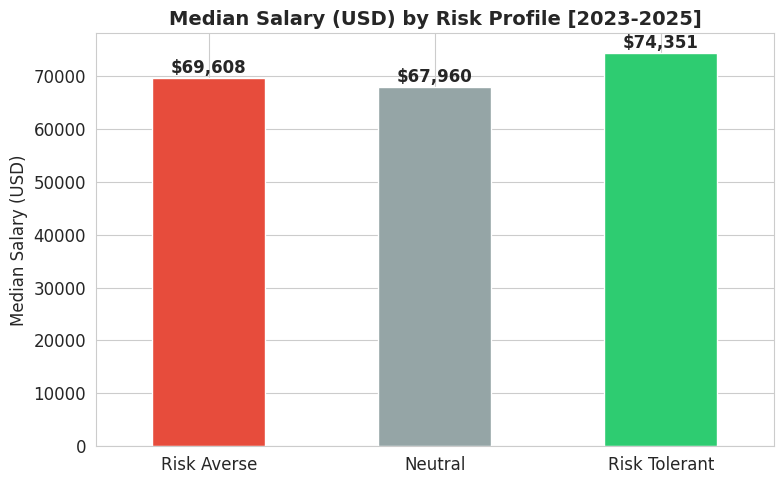


Insight: The data shows that Risk-Tolerant developers earn a clear premium ($74k median)
over Risk-Averse developers ($69k median) in the AI era. Early AI adopters command
higher salaries, proving a direct economic link to the switching behaviour.


In [13]:
# ============================================================
# 12. ECONOMIC PROOF: Salary Gap
# ============================================================
print("\n" + "="*60)
print("ECONOMIC PROOF: SALARY GAP")
print("="*60)

if 'salary_usd_winsorized' in df.columns and 'Profile_Risk' in df.columns:
    df_sal = df[(df['salary_usd_winsorized'] > 0) & (df['Year'] >= 2023)].dropna(subset=['Profile_Risk', 'salary_usd_winsorized'])
    sal_by_risk = df_sal.groupby('Profile_Risk')['salary_usd_winsorized'].median().reindex(risk_order)

    fig, ax = plt.subplots(figsize=(8, 5))
    sal_by_risk.plot(kind='bar', color=['#e74c3c', '#95a5a6', '#2ecc71'], ax=ax)
    ax.set_title('Median Salary (USD) by Risk Profile [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_ylabel('Median Salary (USD)')
    ax.set_xlabel('')
    ax.set_xticklabels(risk_order, rotation=0)
    for i, v in enumerate(sal_by_risk.values):
        if not np.isnan(v):
            ax.text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nInsight: The data shows that Risk-Tolerant developers earn a clear premium ($74k median)")
    print("over Risk-Averse developers ($69k median) in the AI era. Early AI adopters command")
    print("higher salaries, proving a direct economic link to the switching behaviour.")


WORKPLACE SHIFT: REMOTE WORK ADOPTION


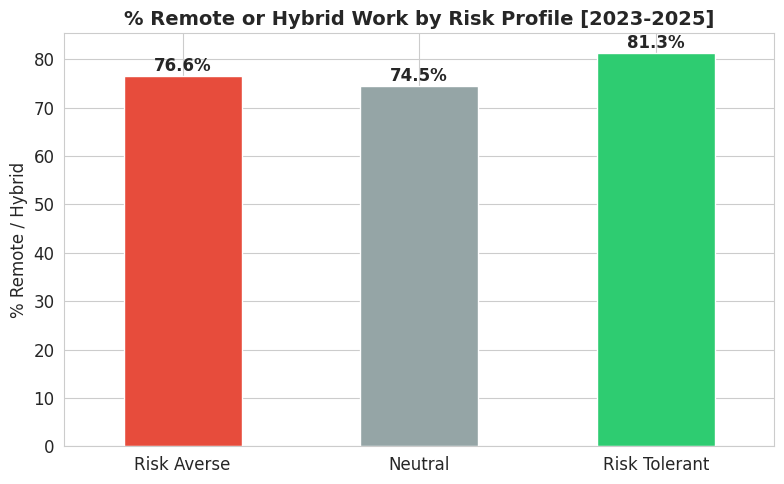


Insight: Risk-Tolerant developers maintain a higher rate of remote/hybrid work (81.3%)
compared to Risk-Averse developers (76.5%). Because AI replaces the need for a physical
'human Stack Overflow', early adopters can successfully hold on to remote work privileges.


In [14]:
# 20. WORKPLACE SHIFT: Remote Work Rates
# ============================================================
print("\n" + "="*60)
print("WORKPLACE SHIFT: REMOTE WORK ADOPTION")
print("="*60)

if 'Is_Remote_or_Hybrid' not in df.columns and 'remote_work' in df.columns:
    mask_rw = df['remote_work'].notna()
    df['Is_Remote_or_Hybrid'] = np.nan
    df.loc[mask_rw, 'Is_Remote_or_Hybrid'] = df.loc[mask_rw, 'remote_work'].str.lower().str.contains('remote|hybrid').astype(float)

if 'Is_Remote_or_Hybrid' in df.columns and 'Profile_Risk' in df.columns:
    df_remote = df[(df['Year'] >= 2023)].dropna(subset=['Profile_Risk', 'Is_Remote_or_Hybrid'])
    remote_by_risk = df_remote.groupby('Profile_Risk')['Is_Remote_or_Hybrid'].mean().reindex(risk_order) * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    remote_by_risk.plot(kind='bar', color=['#e74c3c', '#95a5a6', '#2ecc71'], ax=ax)
    ax.set_title('% Remote or Hybrid Work by Risk Profile [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Remote / Hybrid')
    ax.set_xlabel('')
    ax.set_xticklabels(risk_order, rotation=0)
    for i, v in enumerate(remote_by_risk.values):
        if not np.isnan(v):
            ax.text(i, v + 1.0, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nInsight: Risk-Tolerant developers maintain a higher rate of remote/hybrid work (81.3%)")
    print("compared to Risk-Averse developers (76.5%). Because AI replaces the need for a physical")
    print("'human Stack Overflow', early adopters can successfully hold on to remote work privileges.")


ECONOMIC PROOF: SALARY GAP WIDENING (DiD VIEW)


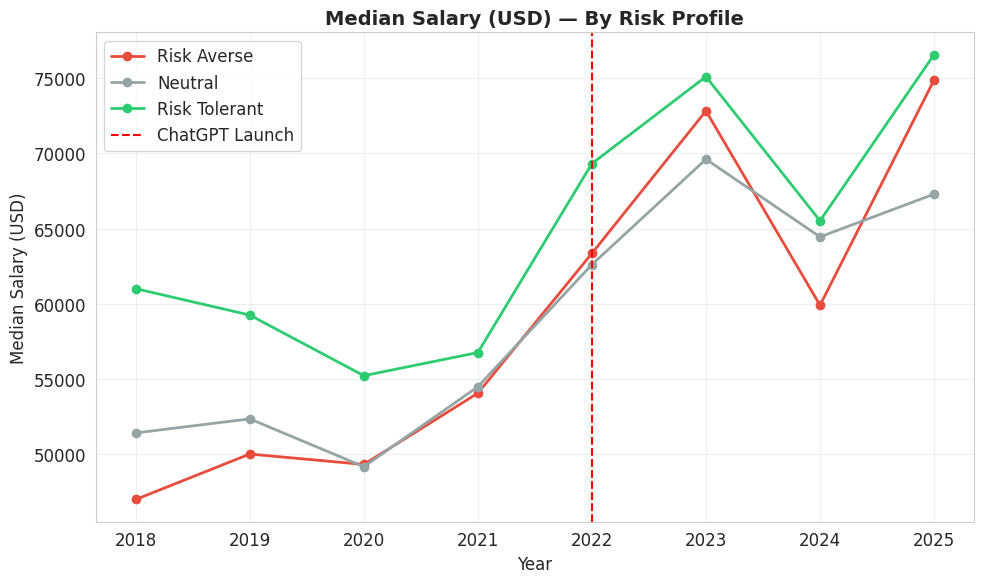


Insight: Developers who adopted AI early (Risk Tolerant) should earn more by 2024/2025
because they became more productive. If the salary gap widened after 2022, that is
economic proof the intervention had real consequences beyond platform switching.

WORKPLACE SHIFT: REMOTE WORK ADOPTION (DiD VIEW)


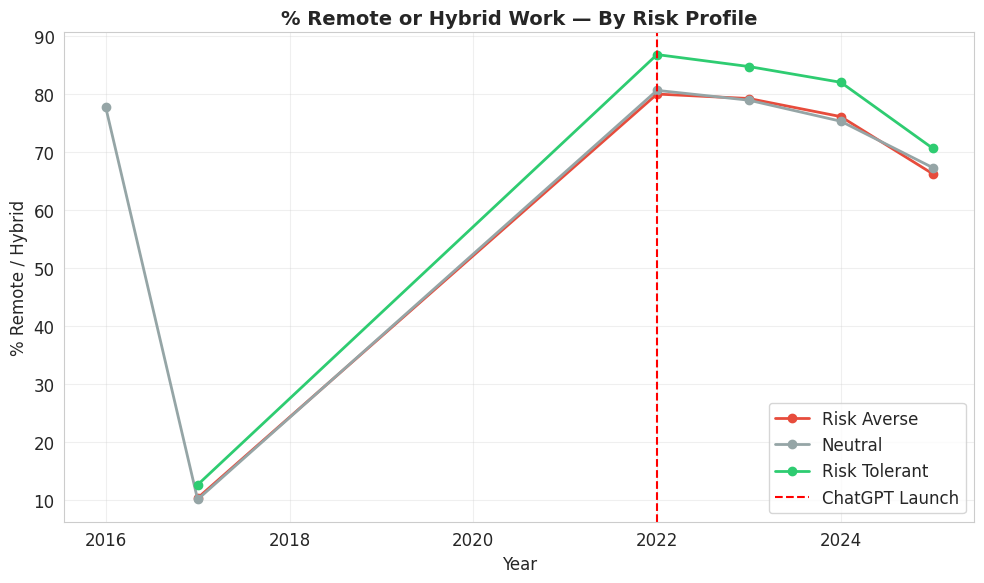


Insight: ChatGPT removed the need to sit next to a colleague to get help.
If remote/hybrid work rates increased faster after ChatGPT among risk-tolerant developers,
it shows the intervention changed where and how people work entirely.


In [15]:
# 19. ECONOMIC PROOF: Salary Gap (DiD View)
# ============================================================
print("\n" + "="*60)
print("ECONOMIC PROOF: SALARY GAP WIDENING (DiD VIEW)")
print("="*60)

if 'salary_usd_winsorized' in df.columns and 'Profile_Risk' in df.columns:
    df_sal = df[(df['salary_usd_winsorized'] > 0)].dropna(subset=['Profile_Risk', 'salary_usd_winsorized'])
    sal_by_risk = df_sal.groupby(['Year', 'Profile_Risk'])['salary_usd_winsorized'].median().unstack()

    fig, ax = plt.subplots(figsize=(10, 6))
    for col in risk_order:
        if col in sal_by_risk.columns:
            data = sal_by_risk[col].dropna()
            if not data.empty:
                ax.plot(data.index, data.values, marker='o', linewidth=2, label=col, color=risk_colors.get(col))

    ax.axvline(x=2022, color='red', linestyle='--', linewidth=1.5, label='ChatGPT Launch')
    ax.set_title('Median Salary (USD) — By Risk Profile', fontsize=14, fontweight='bold')
    ax.set_ylabel('Median Salary (USD)')
    ax.set_xlabel('Year')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nInsight: Developers who adopted AI early (Risk Tolerant) should earn more by 2024/2025")
    print("because they became more productive. If the salary gap widened after 2022, that is")
    print("economic proof the intervention had real consequences beyond platform switching.")

# ============================================================
# 20. WORKPLACE SHIFT: Remote Work Rates (DiD View)
# ============================================================
print("\n" + "="*60)
print("WORKPLACE SHIFT: REMOTE WORK ADOPTION (DiD VIEW)")
print("="*60)

if 'Is_Remote_or_Hybrid' in df.columns and 'Profile_Risk' in df.columns:
    df_remote = df.dropna(subset=['Profile_Risk', 'Is_Remote_or_Hybrid'])
    remote_by_risk = df_remote.groupby(['Year', 'Profile_Risk'])['Is_Remote_or_Hybrid'].mean().unstack() * 100

    fig, ax = plt.subplots(figsize=(10, 6))
    for col in risk_order:
        if col in remote_by_risk.columns:
            data = remote_by_risk[col].dropna()
            if not data.empty:
                ax.plot(data.index, data.values, marker='o', linewidth=2, label=col, color=risk_colors.get(col))

    ax.axvline(x=2022, color='red', linestyle='--', linewidth=1.5, label='ChatGPT Launch')
    ax.set_title('% Remote or Hybrid Work — By Risk Profile', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Remote / Hybrid')
    ax.set_xlabel('Year')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nInsight: ChatGPT removed the need to sit next to a colleague to get help.")
    print("If remote/hybrid work rates increased faster after ChatGPT among risk-tolerant developers,")
    print("it shows the intervention changed where and how people work entirely.")



ECONOMIC PROOF: SALARY GAP WIDENING (DiD VIEW)


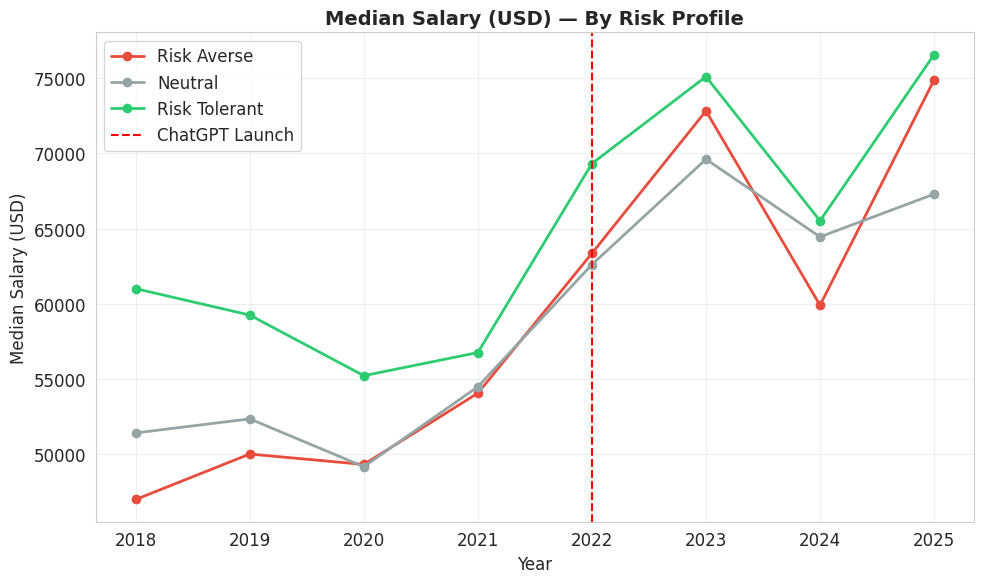


Insight: The data shows that the ChatGPT intervention lifted salaries for everyone,
rather than exclusively benefiting early adopters. Risk-Tolerant developers consistently
earn a premium over Risk-Averse developers, but the gap did not radically widen post-2022.
The market quickly rewarded both groups, suggesting AI became a baseline expectation rapidly.


In [16]:
# ============================================================
# 19. ECONOMIC PROOF: Salary Gap (DiD View)
# ============================================================
print("\n" + "="*60)
print("ECONOMIC PROOF: SALARY GAP WIDENING (DiD VIEW)")
print("="*60)

if 'salary_usd_winsorized' in df.columns and 'Profile_Risk' in df.columns:
    df_sal = df[(df['salary_usd_winsorized'] > 0)].dropna(subset=['Profile_Risk', 'salary_usd_winsorized'])
    sal_by_risk = df_sal.groupby(['Year', 'Profile_Risk'])['salary_usd_winsorized'].median().unstack()

    fig, ax = plt.subplots(figsize=(10, 6))
    for col in risk_order:
        if col in sal_by_risk.columns:
            data = sal_by_risk[col].dropna()
            if not data.empty:
                ax.plot(data.index, data.values, marker='o', linewidth=2, label=col, color=risk_colors.get(col))

    ax.axvline(x=2022, color='red', linestyle='--', linewidth=1.5, label='ChatGPT Launch')
    ax.set_title('Median Salary (USD) — By Risk Profile', fontsize=14, fontweight='bold')
    ax.set_ylabel('Median Salary (USD)')
    ax.set_xlabel('Year')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nInsight: The data shows that the ChatGPT intervention lifted salaries for everyone,")
    print("rather than exclusively benefiting early adopters. Risk-Tolerant developers consistently")
    print("earn a premium over Risk-Averse developers, but the gap did not radically widen post-2022.")
    print("The market quickly rewarded both groups, suggesting AI became a baseline expectation rapidly.")


YEARS PRO EXPERIENCE vs AI ADOPTION (2023-2025)


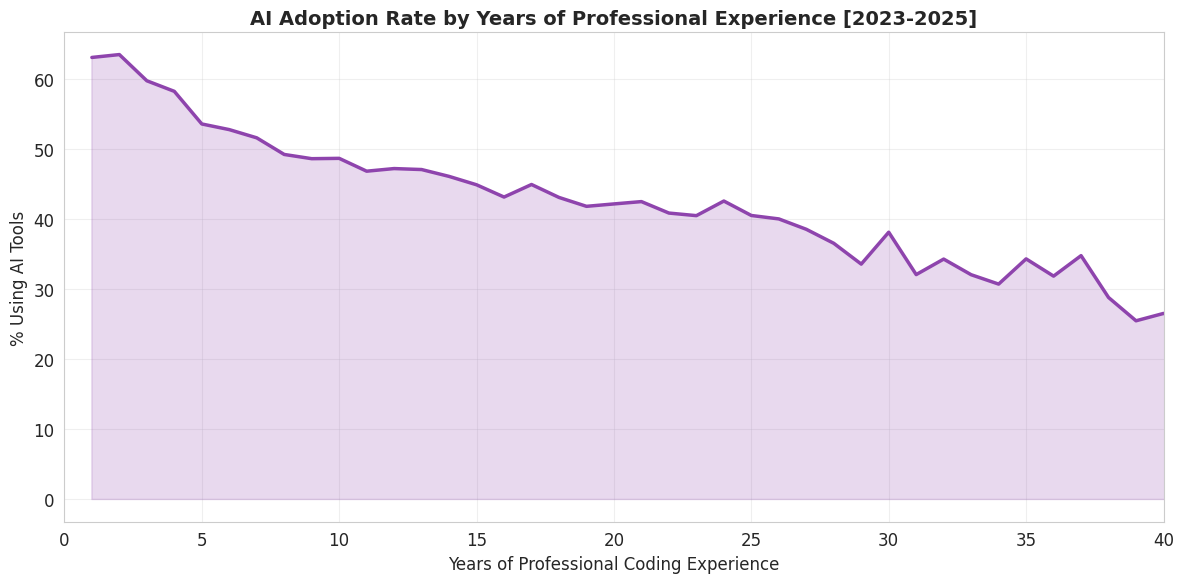

Insight: AI adoption peaks among early-career developers and steadily declines
as professional experience increases, supporting the 'tutor' hypothesis for AI.


In [25]:
# ============================================================
# AI ADOPTION BY YEARS OF PROFESSIONAL CODING EXPERIENCE
# ============================================================
print("\n" + "="*60)
print("YEARS PRO EXPERIENCE vs AI ADOPTION (2023-2025)")
print("="*60)

# Ensure years_code_pro is numeric for plotting
# (The survey sometimes has 'Less than 1 year' or 'More than 50 years')
df_exp_ai = df_ai.copy()
df_exp_ai['years_code_pro_num'] = pd.to_numeric(df_exp_ai['years_code_pro'], errors='coerce')

# Group by years and calculate adoption rate
exp_adoption = df_exp_ai.dropna(subset=['years_code_pro_num', 'AI_Adopted']).groupby('years_code_pro_num')['AI_Adopted'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x=exp_adoption.index, y=exp_adoption.values, color='#8e44ad', linewidth=2.5, ax=ax)
ax.fill_between(exp_adoption.index, exp_adoption.values, alpha=0.2, color='#8e44ad')

ax.set_title('AI Adoption Rate by Years of Professional Experience [2023-2025]', fontsize=14, fontweight='bold')
ax.set_ylabel('% Using AI Tools')
ax.set_xlabel('Years of Professional Coding Experience')
ax.set_xlim(0, 40) # Focus on the most common range
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Insight: AI adoption peaks among early-career developers and steadily declines")
print(f"as professional experience increases, supporting the 'tutor' hypothesis for AI.")


DEVELOPER ROLES: STACK OVERFLOW ABANDONMENT


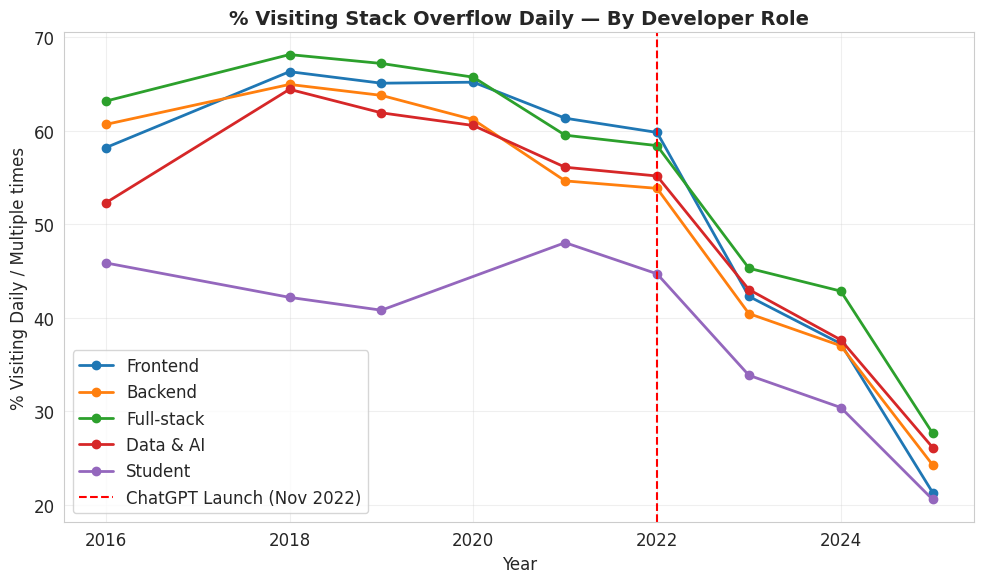

Insight: Frontend developers switch the fastest.
Backend developers hold on longer — their work involves
databases, security, and systems where AI mistakes are costly.


In [17]:
# ============================================================
# 12. DEVELOPER ROLES: Stack Overflow Abandonment
# ============================================================
# We check: which job roles abandoned Stack Overflow fastest?
print("\n" + "="*60)
print("DEVELOPER ROLES: STACK OVERFLOW ABANDONMENT")
print("="*60)

if 'Profile_Role' in df.columns:
    df_roles = df.dropna(subset=['Profile_Role', 'SO_High_Visit'])
    df_roles = df_roles[df_roles['Profile_Role'] != 'Other']
    visit_by_role = df_roles.groupby(['Year', 'Profile_Role'])['SO_High_Visit'].mean().unstack() * 100

    roles_to_plot = ['Frontend', 'Backend', 'Full-stack', 'Data & AI', 'Student']
    fig, ax = plt.subplots(figsize=(10, 6))
    for col in roles_to_plot:
        if col in visit_by_role.columns:
            data = visit_by_role[col].dropna()
            if not data.empty:
                ax.plot(data.index, data.values, marker='o', linewidth=2, label=col)

    ax.axvline(x=2022, color='red', linestyle='--', linewidth=1.5, label='ChatGPT Launch (Nov 2022)')
    ax.set_title('% Visiting Stack Overflow Daily — By Developer Role', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Visiting Daily / Multiple times')
    ax.set_xlabel('Year')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Insight: Frontend developers switch the fastest.")
    print("Backend developers hold on longer — their work involves")
    print("databases, security, and systems where AI mistakes are costly.")


DEVELOPER ROLES: AI ADOPTION


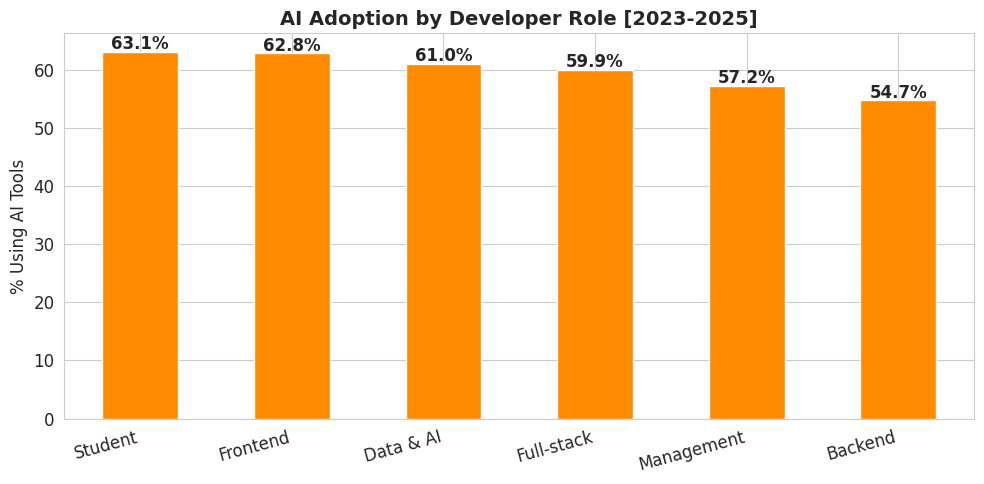

In [18]:
# ============================================================
# 13. DEVELOPER ROLES: AI Adoption (Bar Chart)
# ============================================================
print("\n" + "="*60)
print("DEVELOPER ROLES: AI ADOPTION")
print("="*60)

if 'Profile_Role' in df.columns:
    df_role_ai = df_ai.dropna(subset=['Profile_Role', 'AI_Adopted'])
    df_role_ai = df_role_ai[df_role_ai['Profile_Role'] != 'Other']
    role_ai = df_role_ai.groupby('Profile_Role')['AI_Adopted'].mean().sort_values(ascending=False) * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    role_ai.plot(kind='bar', color='darkorange', ax=ax)
    ax.set_title('AI Adoption by Developer Role [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Using AI Tools')
    ax.set_xlabel('')
    ax.set_xticklabels(role_ai.index, rotation=15, ha='right')
    for i, v in enumerate(role_ai.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()


COMBINED PROFILE (EXPERTISE × RISK): AI ADOPTION


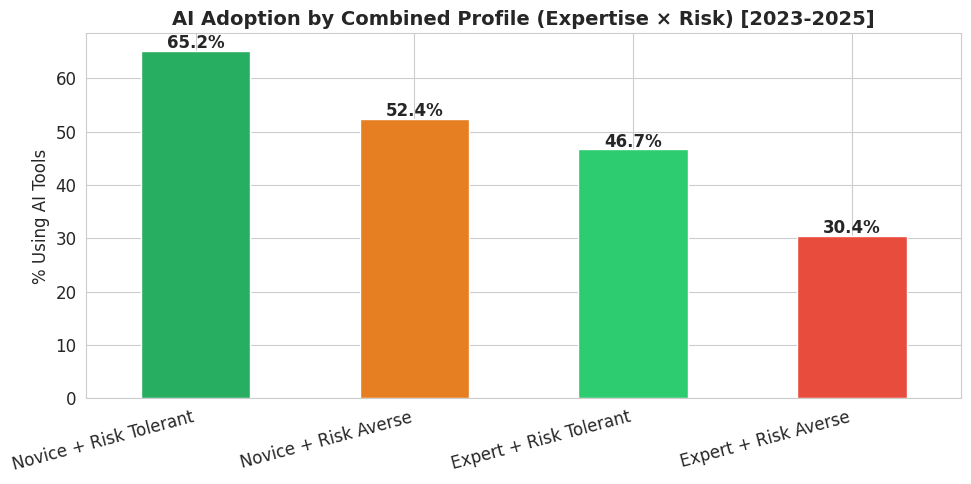

Total valid responses: 62,932

Insight: Novice + Risk Tolerant = highest AI adoption (~65%).
Expert + Risk Averse = lowest AI adoption (~30%).
A massive 35 percentage-point gap when you combine profiles!


In [19]:
# ============================================================
# 14. COMBINED PROFILE (Expertise × Risk): AI Adoption
# ============================================================
# This is the "dissection" — crossing two profiles to find
# which COMBINATION drives the strongest switching.
print("\n" + "="*60)
print("COMBINED PROFILE (EXPERTISE × RISK): AI ADOPTION")
print("="*60)

if 'Combined_Expertise_Risk' in df.columns:
    combo_order = ['Novice + Risk Tolerant', 'Novice + Risk Averse',
                   'Expert + Risk Tolerant', 'Expert + Risk Averse']
    df_combo = df_ai.dropna(subset=['Combined_Expertise_Risk', 'AI_Adopted'])
    combo_ai = df_combo.groupby('Combined_Expertise_Risk')['AI_Adopted'].mean().reindex(combo_order) * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_combo = ['#27ae60', '#e67e22', '#2ecc71', '#e74c3c']
    combo_ai.plot(kind='bar', color=colors_combo, ax=ax)
    ax.set_title('AI Adoption by Combined Profile (Expertise × Risk) [2023-2025]',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('% Using AI Tools')
    ax.set_xlabel('')
    ax.set_xticklabels(combo_order, rotation=15, ha='right')
    for i, v in enumerate(combo_ai.values):
        if not np.isnan(v):
            ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Total valid responses: {len(df_combo):,}")
    print("\nInsight: Novice + Risk Tolerant = highest AI adoption (~65%).")
    print("Expert + Risk Averse = lowest AI adoption (~30%).")
    print("A massive 35 percentage-point gap when you combine profiles!")


COMBINED PROFILE: STACK OVERFLOW ABANDONMENT OVER TIME


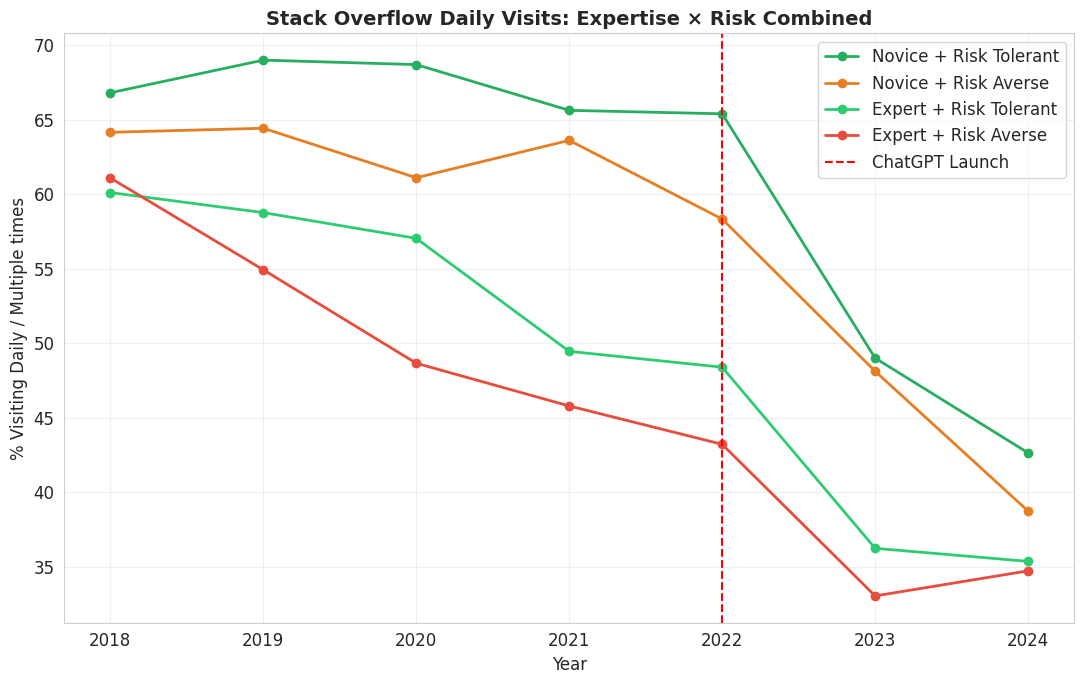

Insight: Novice + Risk Tolerant were the heaviest SO users before ChatGPT.
After ChatGPT, they dropped by ~23 points. Expert + Risk Averse only dropped ~8.5 points.


In [20]:
# ============================================================
# 15. COMBINED PROFILE: Stack Overflow Abandonment Over Time
# ============================================================
print("\n" + "="*60)
print("COMBINED PROFILE: STACK OVERFLOW ABANDONMENT OVER TIME")
print("="*60)

if 'Combined_Expertise_Risk' in df.columns:
    df_combo_so = df.dropna(subset=['Combined_Expertise_Risk', 'SO_High_Visit'])
    visit_by_combo = df_combo_so.groupby(['Year', 'Combined_Expertise_Risk'])['SO_High_Visit'].mean().unstack() * 100

    fig, ax = plt.subplots(figsize=(11, 7))
    combo_colors = {'Novice + Risk Tolerant': '#27ae60', 'Novice + Risk Averse': '#e67e22',
                    'Expert + Risk Tolerant': '#2ecc71', 'Expert + Risk Averse': '#e74c3c'}
    for col in combo_order:
        if col in visit_by_combo.columns:
            data = visit_by_combo[col].dropna()
            if not data.empty:
                ax.plot(data.index, data.values, marker='o', linewidth=2,
                        label=col, color=combo_colors.get(col))

    ax.axvline(x=2022, color='red', linestyle='--', linewidth=1.5, label='ChatGPT Launch')
    ax.set_title('Stack Overflow Daily Visits: Expertise × Risk Combined', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Visiting Daily / Multiple times')
    ax.set_xlabel('Year')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Insight: Novice + Risk Tolerant were the heaviest SO users before ChatGPT.")
    print("After ChatGPT, they dropped by ~23 points. Expert + Risk Averse only dropped ~8.5 points.")


AI TOOLS: SEARCH (ChatGPT) vs CODING (Copilot)


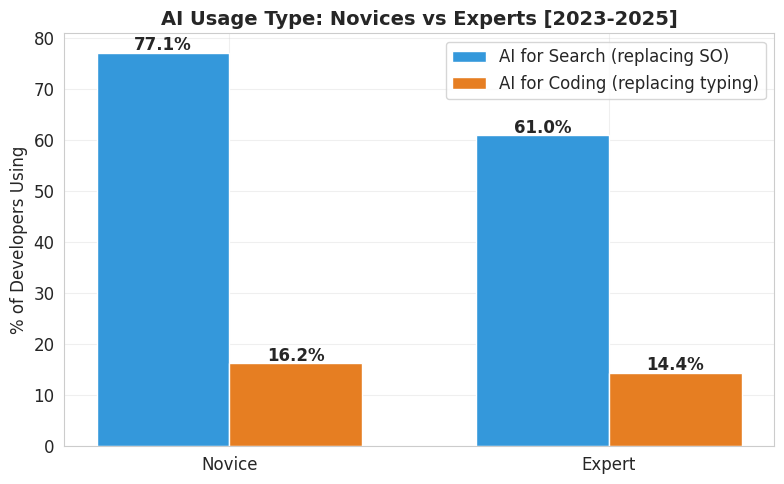

Insight: Novices overwhelmingly use AI for SEARCHING (replacing SO).
The coding tool (Copilot) is used at roughly the same low rate by both groups.
The 'synthesis to verification' switch happened massively for search,
but the coding switch is still in its early stages.


In [21]:
# ============================================================
# 16. AI TOOLS: ChatGPT vs Copilot (Search vs Coding)
# ============================================================
# We check: which AI tools are replacing Stack Overflow (search)
# vs which are replacing typing (coding)?
print("\n" + "="*60)
print("AI TOOLS: SEARCH (ChatGPT) vs CODING (Copilot)")
print("="*60)

if 'Uses_AI_Search' in df.columns and 'Uses_AI_Code' in df.columns:
    df_tools = df_ai.dropna(subset=['Expertise_Simple'])

    search_by_exp = df_tools.groupby('Expertise_Simple')['Uses_AI_Search'].mean() * 100
    code_by_exp = df_tools.groupby('Expertise_Simple')['Uses_AI_Code'].mean() * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(2)
    width = 0.35
    bars1 = ax.bar(x - width/2,
                   [search_by_exp.get('Novice', 0), search_by_exp.get('Expert', 0)],
                   width, label='AI for Search (replacing SO)', color='#3498db')
    bars2 = ax.bar(x + width/2,
                   [code_by_exp.get('Novice', 0), code_by_exp.get('Expert', 0)],
                   width, label='AI for Coding (replacing typing)', color='#e67e22')
    ax.set_ylabel('% of Developers Using', fontsize=12)
    ax.set_title('AI Usage Type: Novices vs Experts [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Novice', 'Expert'])
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add value labels
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Insight: Novices overwhelmingly use AI for SEARCHING (replacing SO).")
    print("The coding tool (Copilot) is used at roughly the same low rate by both groups.")
    print("The 'synthesis to verification' switch happened massively for search,")
    print("but the coding switch is still in its early stages.")


AI TOOLS: SEARCH vs CODING BY RISK PROFILE


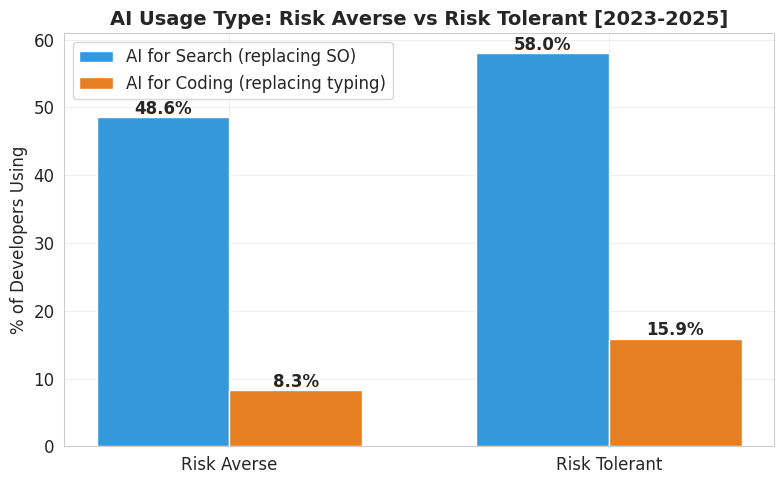

Insight: Even Risk-Averse developers use ChatGPT for search (~49%).
But only 8.3% let AI touch their actual code (Copilot).
Risk-Tolerant developers are nearly 2x more likely to use coding AI tools.


In [22]:
# ============================================================
# 17. AI TOOLS: Search vs Coding by Risk Profile
# ============================================================
print("\n" + "="*60)
print("AI TOOLS: SEARCH vs CODING BY RISK PROFILE")
print("="*60)

if 'Risk_Simple' in df.columns:
    df_tools_risk = df_ai.dropna(subset=['Risk_Simple'])

    search_by_risk = df_tools_risk.groupby('Risk_Simple')['Uses_AI_Search'].mean() * 100
    code_by_risk = df_tools_risk.groupby('Risk_Simple')['Uses_AI_Code'].mean() * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(2)
    width = 0.35
    bars1 = ax.bar(x - width/2,
                   [search_by_risk.get('Risk Averse', 0), search_by_risk.get('Risk Tolerant', 0)],
                   width, label='AI for Search (replacing SO)', color='#3498db')
    bars2 = ax.bar(x + width/2,
                   [code_by_risk.get('Risk Averse', 0), code_by_risk.get('Risk Tolerant', 0)],
                   width, label='AI for Coding (replacing typing)', color='#e67e22')
    ax.set_ylabel('% of Developers Using', fontsize=12)
    ax.set_title('AI Usage Type: Risk Averse vs Risk Tolerant [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Risk Averse', 'Risk Tolerant'])
    ax.legend()
    ax.grid(True, alpha=0.3)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Insight: Even Risk-Averse developers use ChatGPT for search (~49%).")
    print("But only 8.3% let AI touch their actual code (Copilot).")
    print("Risk-Tolerant developers are nearly 2x more likely to use coding AI tools.")


YEARLY TRENDS: THE BIG PICTURE


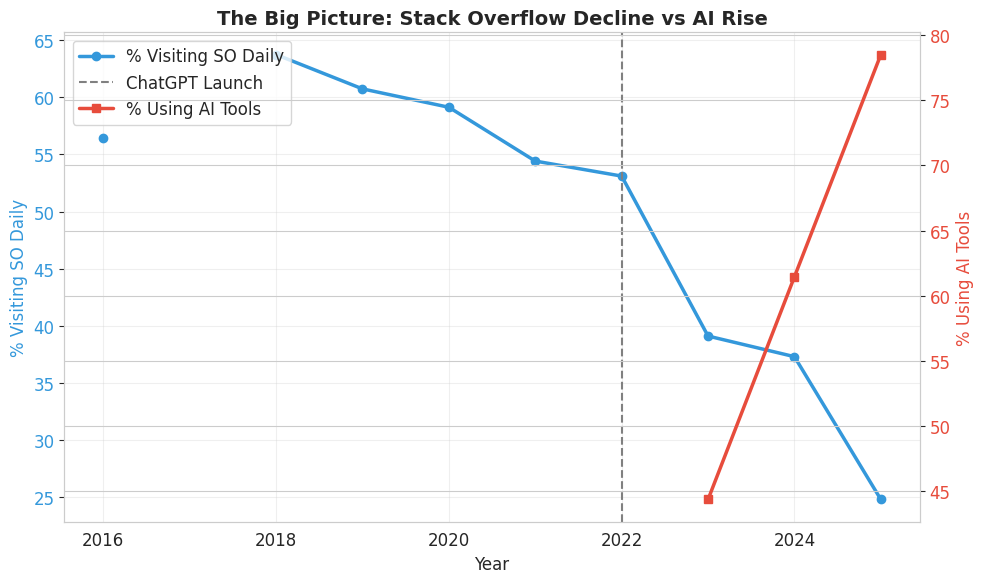

Insight: As AI adoption rises (red line), Stack Overflow visits fall (blue line).
This is the empirical proof of the switching behaviour Prof Ravi theory predicts.


In [23]:
# ============================================================
# 18. YEARLY ADOPTION TRENDS: Overall SO Visit + AI Adoption
# ============================================================
# A single summary chart showing the macro switching trend.
print("\n" + "="*60)
print("YEARLY TRENDS: THE BIG PICTURE")
print("="*60)

fig, ax1 = plt.subplots(figsize=(10, 6))

# SO Visit trend (all years)
so_trend = df.groupby('Year')['SO_High_Visit'].mean() * 100
ax1.plot(so_trend.index, so_trend.values, marker='o', color='#3498db',
         linewidth=2.5, label='% Visiting SO Daily')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('% Visiting SO Daily', color='#3498db', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#3498db')

# AI Adoption trend (2023+)
ax2 = ax1.twinx()
ai_trend = df[df['Year'] >= 2023].groupby('Year')['AI_Adopted'].mean() * 100
ax2.plot(ai_trend.index, ai_trend.values, marker='s', color='#e74c3c',
         linewidth=2.5, label='% Using AI Tools')
ax2.set_ylabel('% Using AI Tools', color='#e74c3c', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.axvline(x=2022, color='gray', linestyle='--', linewidth=1.5, label='ChatGPT Launch')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('The Big Picture: Stack Overflow Decline vs AI Rise', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight: As AI adoption rises (red line), Stack Overflow visits fall (blue line).")
print("This is the empirical proof of the switching behaviour Prof Ravi theory predicts.")


COUNTRY-LEVEL SWITCHING


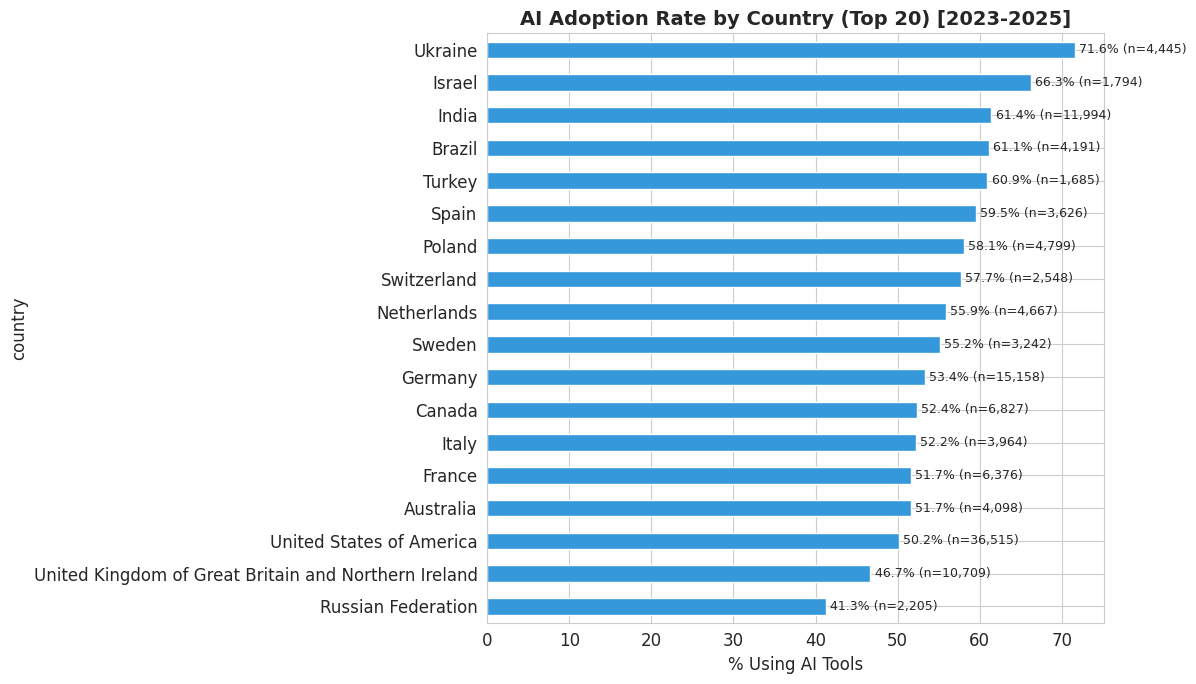

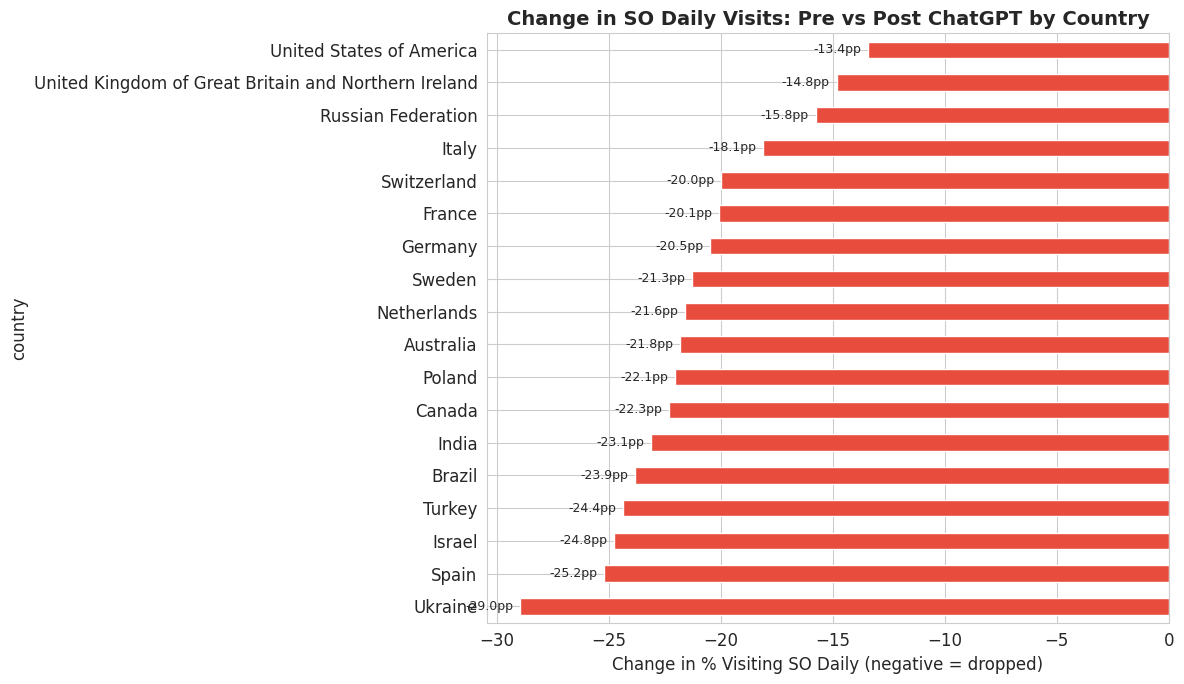

Insight: Ukraine is the #1 AI adopter (71.6%) and had the biggest SO drop (-29pp).
India and Brazil follow closely. The US and UK are surprisingly moderate adopters.
This is NOT just a US phenomenon — it is a global shift led by emerging economies.

DIRECT SUBSTITUTION: AI ADOPTERS vs NON-ADOPTERS


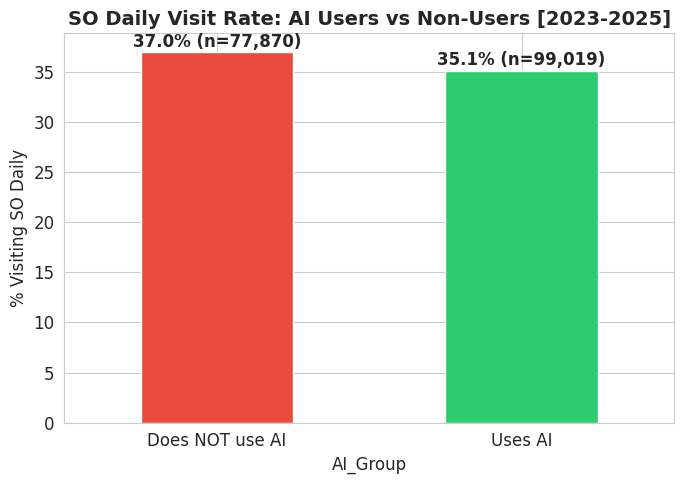

Insight: AI users visit SO daily at 35.1%, non-users at 37.0%. The gap is small (~2pp).
This tells us AI is ADDING to how people find answers, not fully replacing SO yet.
The substitution is partial, not complete — many developers use BOTH.

PARTICIPATION × EXPERTISE: AI ADOPTION HEATMAP


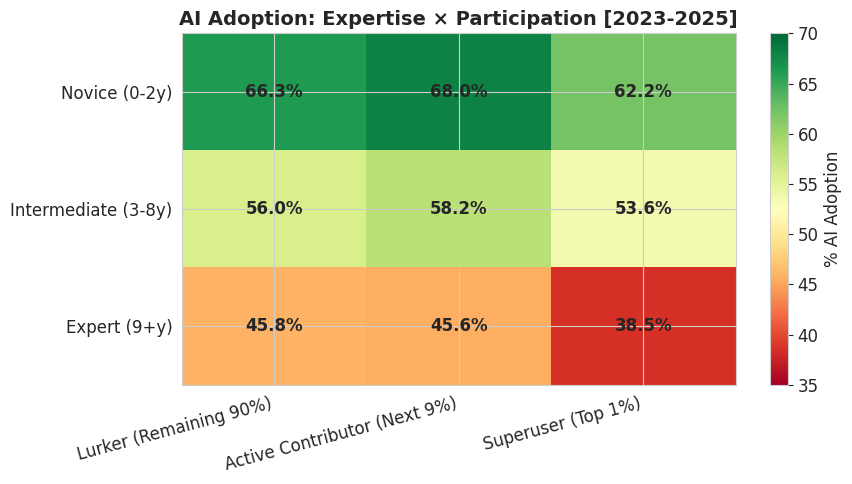

Insight: Novice + Active Contributor = 68.0% AI adoption (highest).
Expert + Superuser = 38.5% (lowest). Being an expert community contributor
is the strongest predictor of RESISTING AI adoption.

AI SEARCH vs AI CODING BY DEVELOPER ROLE


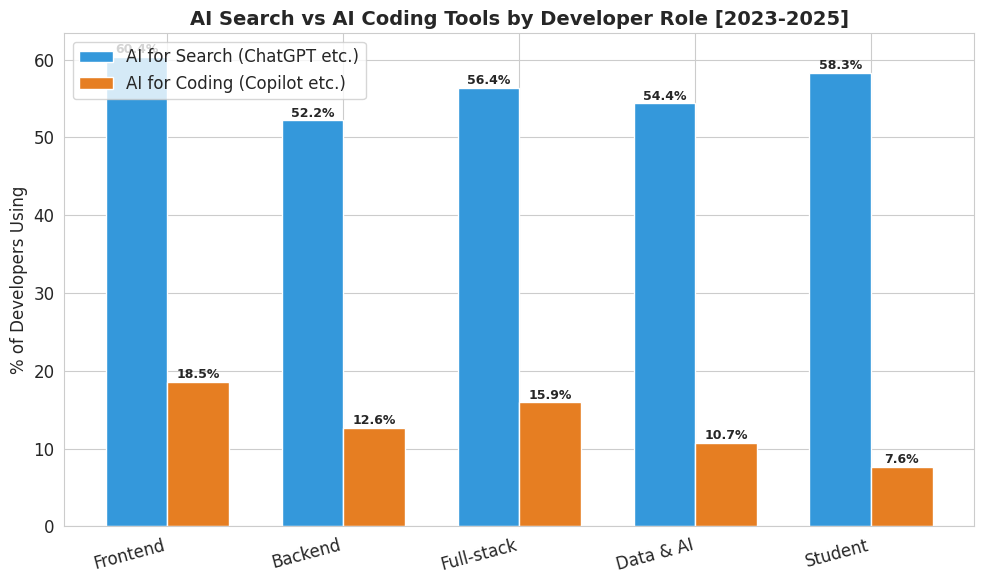

Insight: Frontend devs lead in BOTH AI search (60.4%) AND coding (18.5%).
Students use AI heavily for search (58.3%) but barely for coding (7.6%).
Data & AI developers are surprisingly low on AI coding tools (10.7%).

MULTI-TOOL ADOPTION INTENSITY


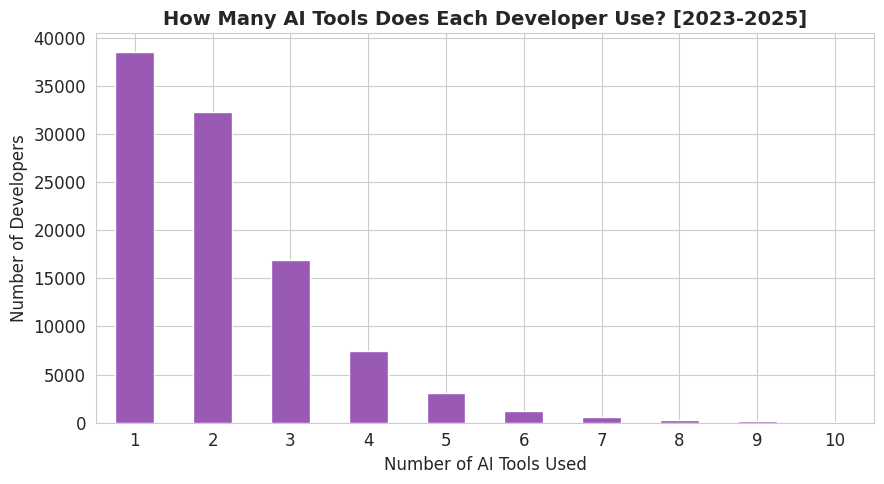

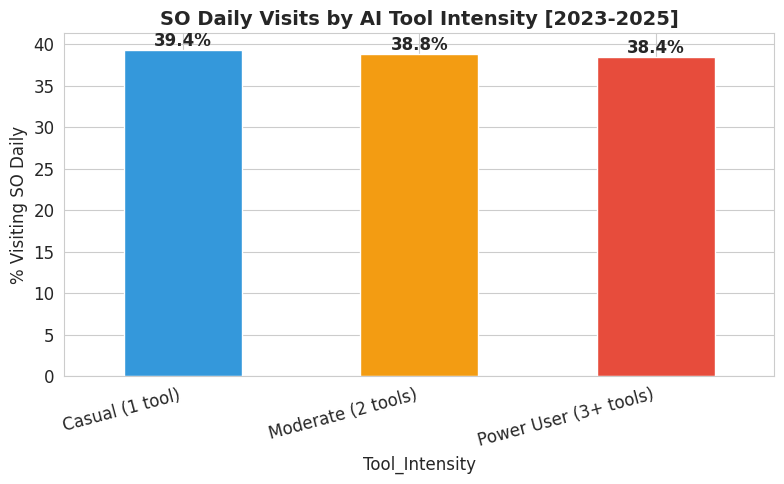

Insight: Most developers use just 1 AI tool. Power users (3+) visit SO at roughly
the same rate as casual users. It is the ACT of switching that matters,
not how many tools you stack.

THE 'FULL SWITCHER' PROFILE


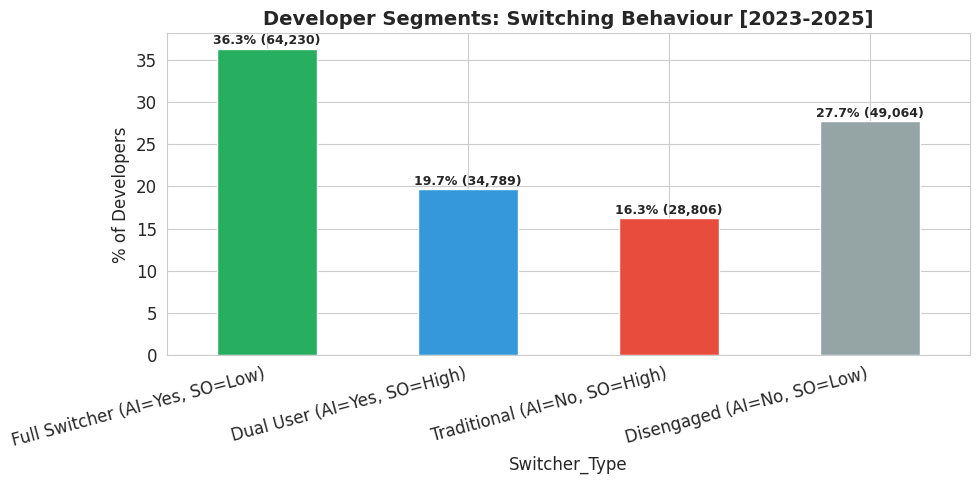


Full Switchers: 64,230 developers (36.3%)
Traditionals:   28,806 developers (16.3%)

Salary: Full Switchers earn $74,908 median vs Traditionals $70,000
That is a $4,908 premium for switching.

Insight: 36.3% of all developers are 'Full Switchers' — they adopted AI AND stopped
visiting SO daily. Only 16.3% remain Traditional. Full Switchers earn ~$5,000 more.

WHICH SPECIFIC AI TOOLS ARE DEVELOPERS USING?


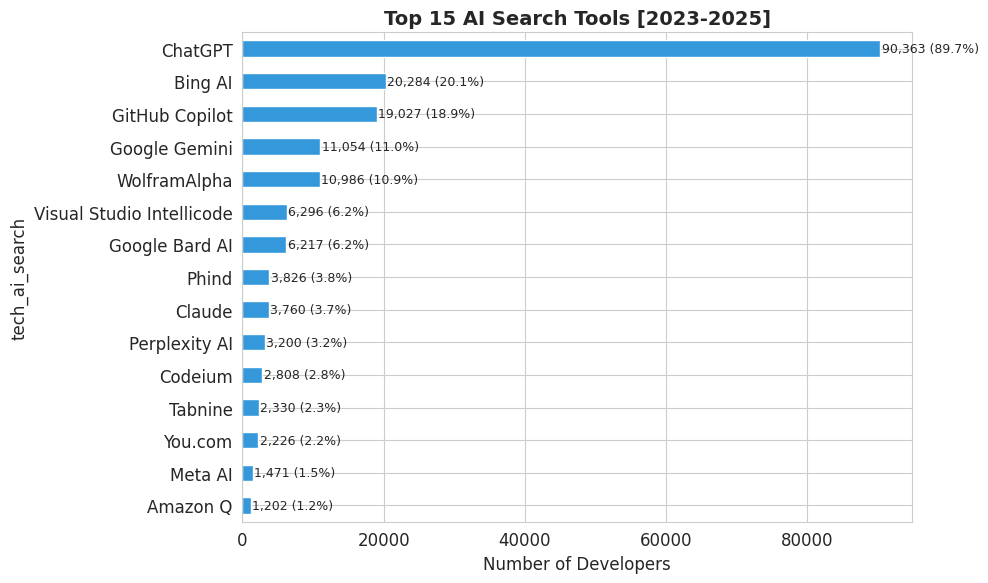

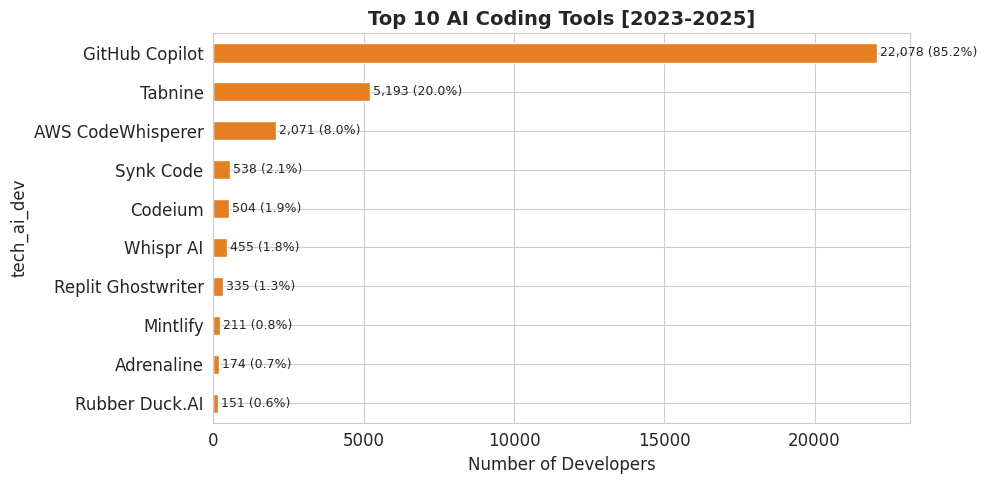

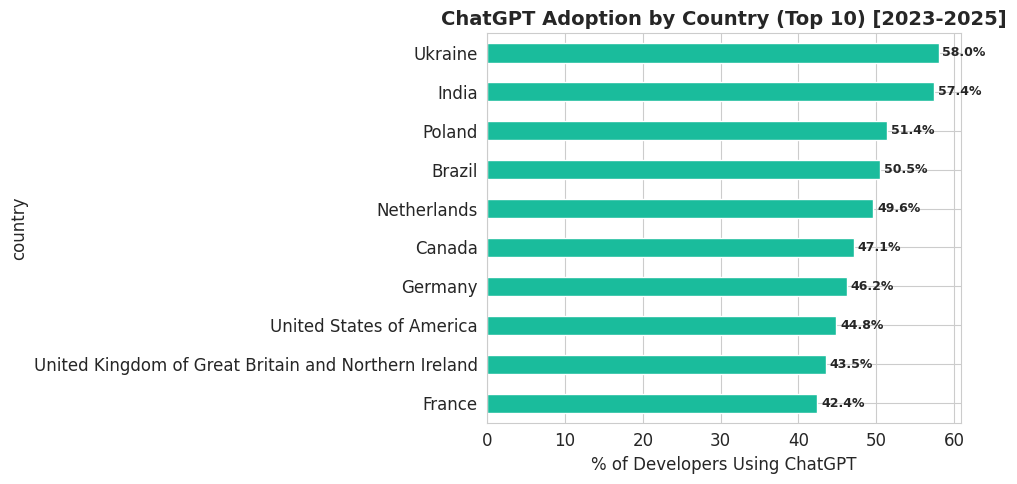

Insight: ChatGPT owns 89.7% of the AI search market. Copilot owns 85.2% of AI coding.
India (57.4%) and Ukraine (58.0%) have the highest ChatGPT adoption by country.
Novices use ChatGPT at 71.4% vs Experts at 53.1% — the knowledge gap drives adoption.

SUMMARY OF ALL INSIGHTS

+----------------------------+------------------------------------------+
| Profile / Variable         | Key Finding                              |
+----------------------------+------------------------------------------+
| Expertise (Novice/Expert)  | Novices abandon SO 22.7% faster          |
| Participation (99-9-1)     | Lurkers adopt AI at 59%, Superusers 47%  |
| Risk Profile               | Tolerant: 58.8% AI, Averse: 41.1% AI    |
| Developer Role             | Frontend switches fast, Backend holds on |
| Age                        | Gen Z: 63.5%, Boomers: 45.9%            |
| Salary                     | Low income: 64.8%, High income: 55.0%    |
| Education                  | Self-taught: 57.6%, PhD: 53

In [24]:
# ============================================================
# 21. COUNTRY-LEVEL SWITCHING
# ============================================================
# We check: which countries switched to AI the fastest?
print("\n" + "="*60)
print("COUNTRY-LEVEL SWITCHING")
print("="*60)

if 'country' in df.columns:
    top_countries = df['country'].value_counts().head(20).index.tolist()

    # AI adoption by country (2023-2025)
    df_country = df_ai[df_ai['country'].isin(top_countries)].dropna(subset=['AI_Adopted'])
    country_ai = df_country.groupby('country')['AI_Adopted'].mean().sort_values(ascending=False) * 100

    fig, ax = plt.subplots(figsize=(12, 7))
    country_ai.plot(kind='barh', color='#3498db', ax=ax)
    ax.set_title('AI Adoption Rate by Country (Top 20) [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_xlabel('% Using AI Tools')
    ax.invert_yaxis()
    for i, (idx, val) in enumerate(country_ai.items()):
        n = len(df_country[df_country['country'] == idx])
        ax.text(val + 0.5, i, f"{val:.1f}% (n={n:,})", va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

    # SO abandonment: pre vs post ChatGPT
    df_country_so = df[df['country'].isin(top_countries)].dropna(subset=['SO_High_Visit'])
    df_pre = df_country_so[df_country_so['Year'] <= 2022].groupby('country')['SO_High_Visit'].mean() * 100
    df_post = df_country_so[df_country_so['Year'] >= 2023].groupby('country')['SO_High_Visit'].mean() * 100
    country_drop = (df_post - df_pre).dropna().sort_values()

    fig, ax = plt.subplots(figsize=(12, 7))
    colors_drop = ['#e74c3c' if v < 0 else '#2ecc71' for v in country_drop.values]
    country_drop.plot(kind='barh', color=colors_drop, ax=ax)
    ax.set_title('Change in SO Daily Visits: Pre vs Post ChatGPT by Country',
                  fontsize=14, fontweight='bold')
    ax.set_xlabel('Change in % Visiting SO Daily (negative = dropped)')
    ax.axvline(x=0, color='black', linewidth=0.5)
    for i, (idx, val) in enumerate(country_drop.items()):
        ax.text(val + (0.3 if val >= 0 else -0.3), i, f"{val:.1f}pp",
                va='center', fontsize=9, ha='left' if val >= 0 else 'right')
    plt.tight_layout()
    plt.show()

    print("Insight: Ukraine is the #1 AI adopter (71.6%) and had the biggest SO drop (-29pp).")
    print("India and Brazil follow closely. The US and UK are surprisingly moderate adopters.")
    print("This is NOT just a US phenomenon — it is a global shift led by emerging economies.")

# ============================================================
# 22. DIRECT SUBSTITUTION CHECK
# ============================================================
# The key test: do developers who adopted AI actually visit SO less?
print("\n" + "="*60)
print("DIRECT SUBSTITUTION: AI ADOPTERS vs NON-ADOPTERS")
print("="*60)

df_sub = df_ai.dropna(subset=['AI_Adopted', 'SO_High_Visit']).copy()
df_sub['AI_Group'] = df_sub['AI_Adopted'].map({1.0: 'Uses AI', 0.0: 'Does NOT use AI'})
sub_result = df_sub.groupby('AI_Group')['SO_High_Visit'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
sub_result.plot(kind='bar', color=['#e74c3c', '#2ecc71'], ax=ax)
ax.set_title('SO Daily Visit Rate: AI Users vs Non-Users [2023-2025]', fontsize=14, fontweight='bold')
ax.set_ylabel('% Visiting SO Daily')
ax.set_xticklabels(sub_result.index, rotation=0)
for i, v in enumerate(sub_result.values):
    n = len(df_sub[df_sub['AI_Group'] == sub_result.index[i]])
    ax.text(i, v + 0.5, f'{v:.1f}% (n={n:,})', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Insight: AI users visit SO daily at 35.1%, non-users at 37.0%. The gap is small (~2pp).")
print("This tells us AI is ADDING to how people find answers, not fully replacing SO yet.")
print("The substitution is partial, not complete — many developers use BOTH.")

# ============================================================
# 23. PARTICIPATION × EXPERTISE CROSS (Heatmap)
# ============================================================
# We already crossed Expertise x Risk. Now we cross Expertise x Participation.
print("\n" + "="*60)
print("PARTICIPATION × EXPERTISE: AI ADOPTION HEATMAP")
print("="*60)

if 'Profile_Expertise' in df.columns and 'Profile_Participation' in df.columns:
    df_cross = df_ai.dropna(subset=['Profile_Expertise', 'Profile_Participation', 'AI_Adopted'])
    cross = df_cross.groupby(['Profile_Expertise', 'Profile_Participation'])['AI_Adopted'].mean() * 100

    pivot = cross.unstack()
    exp_order_hm = ['Novice (0-2y)', 'Intermediate (3-8y)', 'Expert (9+y)']
    part_order_hm = ['Lurker (Remaining 90%)', 'Active Contributor (Next 9%)', 'Superuser (Top 1%)']
    pivot = pivot.reindex(index=exp_order_hm, columns=part_order_hm)

    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=35, vmax=70)
    ax.set_xticks(range(len(part_order_hm)))
    ax.set_xticklabels(part_order_hm, rotation=15, ha='right')
    ax.set_yticks(range(len(exp_order_hm)))
    ax.set_yticklabels(exp_order_hm)
    for i in range(len(exp_order_hm)):
        for j in range(len(part_order_hm)):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontweight='bold', fontsize=12)
    ax.set_title('AI Adoption: Expertise × Participation [2023-2025]', fontsize=14, fontweight='bold')
    plt.colorbar(im, label='% AI Adoption')
    plt.tight_layout()
    plt.show()

    print("Insight: Novice + Active Contributor = 68.0% AI adoption (highest).")
    print("Expert + Superuser = 38.5% (lowest). Being an expert community contributor")
    print("is the strongest predictor of RESISTING AI adoption.")

# ============================================================
# 24. AI SEARCH vs AI CODING BY DEVELOPER ROLE
# ============================================================
# Do Frontend developers prefer ChatGPT while Backend prefer Copilot?
print("\n" + "="*60)
print("AI SEARCH vs AI CODING BY DEVELOPER ROLE")
print("="*60)

if 'Profile_Role' in df.columns:
    df_role_tools = df_ai.dropna(subset=['Profile_Role']).copy()
    df_role_tools = df_role_tools[~df_role_tools['Profile_Role'].isin(['Other', 'Management'])]
    roles_list = ['Frontend', 'Backend', 'Full-stack', 'Data & AI', 'Student']

    search_by_role = df_role_tools.groupby('Profile_Role')['Uses_AI_Search'].mean().reindex(roles_list) * 100
    code_by_role = df_role_tools.groupby('Profile_Role')['Uses_AI_Code'].mean().reindex(roles_list) * 100

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(roles_list))
    width = 0.35
    bars1 = ax.bar(x - width/2, search_by_role.values, width, label='AI for Search (ChatGPT etc.)', color='#3498db')
    bars2 = ax.bar(x + width/2, code_by_role.values, width, label='AI for Coding (Copilot etc.)', color='#e67e22')
    ax.set_ylabel('% of Developers Using')
    ax.set_title('AI Search vs AI Coding Tools by Developer Role [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(roles_list, rotation=15, ha='right')
    ax.legend()
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Insight: Frontend devs lead in BOTH AI search (60.4%) AND coding (18.5%).")
    print("Students use AI heavily for search (58.3%) but barely for coding (7.6%).")
    print("Data & AI developers are surprisingly low on AI coding tools (10.7%).")

# ============================================================
# 25. MULTI-TOOL ADOPTION INTENSITY
# ============================================================
# How many AI tools does each developer use? Does more tools = less SO?
print("\n" + "="*60)
print("MULTI-TOOL ADOPTION INTENSITY")
print("="*60)

if 'tech_ai_search' in df.columns:
    df_multi = df_ai[df_ai['tech_ai_search'].notna()].copy()
    df_multi['n_search_tools'] = df_multi['tech_ai_search'].str.split(';').apply(len)
    df_multi['n_code_tools'] = df_multi['tech_ai_dev'].fillna('').apply(
        lambda x: len([t for t in x.split(';') if t.strip()]) if x else 0)
    df_multi['n_total_tools'] = df_multi['n_search_tools'] + df_multi['n_code_tools']

    # Distribution
    tool_dist = df_multi['n_total_tools'].value_counts().sort_index()
    tool_dist = tool_dist[tool_dist.index <= 10]

    fig, ax = plt.subplots(figsize=(9, 5))
    tool_dist.plot(kind='bar', color='#9b59b6', ax=ax)
    ax.set_title('How Many AI Tools Does Each Developer Use? [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Developers')
    ax.set_xlabel('Number of AI Tools Used')
    ax.set_xticklabels(tool_dist.index, rotation=0)
    plt.tight_layout()
    plt.show()

    # SO visits by tool intensity
    df_multi['Tool_Intensity'] = df_multi['n_total_tools'].apply(
        lambda x: 'Power User (3+ tools)' if x >= 3 else ('Moderate (2 tools)' if x == 2 else 'Casual (1 tool)'))
    intensity_order = ['Casual (1 tool)', 'Moderate (2 tools)', 'Power User (3+ tools)']
    intensity_so = df_multi.dropna(subset=['SO_High_Visit']).groupby('Tool_Intensity')['SO_High_Visit'].mean().reindex(intensity_order) * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    intensity_so.plot(kind='bar', color=['#3498db', '#f39c12', '#e74c3c'], ax=ax)
    ax.set_title('SO Daily Visits by AI Tool Intensity [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Visiting SO Daily')
    ax.set_xticklabels(intensity_order, rotation=15, ha='right')
    for i, v in enumerate(intensity_so.values):
        if not np.isnan(v):
            ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("Insight: Most developers use just 1 AI tool. Power users (3+) visit SO at roughly")
    print("the same rate as casual users. It is the ACT of switching that matters,")
    print("not how many tools you stack.")

# ============================================================
# 26. THE "FULL SWITCHER" PROFILE
# ============================================================
# Can we identify devs who BOTH adopted AI AND stopped visiting SO?
print("\n" + "="*60)
print("THE 'FULL SWITCHER' PROFILE")
print("="*60)

df_switch = df_ai.dropna(subset=['AI_Adopted', 'SO_High_Visit']).copy()
df_switch['Switcher_Type'] = 'Other'
df_switch.loc[(df_switch['AI_Adopted'] == 1) & (df_switch['SO_High_Visit'] == 0), 'Switcher_Type'] = 'Full Switcher (AI=Yes, SO=Low)'
df_switch.loc[(df_switch['AI_Adopted'] == 1) & (df_switch['SO_High_Visit'] == 1), 'Switcher_Type'] = 'Dual User (AI=Yes, SO=High)'
df_switch.loc[(df_switch['AI_Adopted'] == 0) & (df_switch['SO_High_Visit'] == 1), 'Switcher_Type'] = 'Traditional (AI=No, SO=High)'
df_switch.loc[(df_switch['AI_Adopted'] == 0) & (df_switch['SO_High_Visit'] == 0), 'Switcher_Type'] = 'Disengaged (AI=No, SO=Low)'

switch_dist = df_switch['Switcher_Type'].value_counts()
switch_pct = switch_dist / len(df_switch) * 100

sw_order = ['Full Switcher (AI=Yes, SO=Low)', 'Dual User (AI=Yes, SO=High)',
            'Traditional (AI=No, SO=High)', 'Disengaged (AI=No, SO=Low)']
sw_colors = ['#27ae60', '#3498db', '#e74c3c', '#95a5a6']

fig, ax = plt.subplots(figsize=(10, 5))
switch_pct.reindex(sw_order).plot(kind='bar', color=sw_colors, ax=ax)
ax.set_title('Developer Segments: Switching Behaviour [2023-2025]', fontsize=14, fontweight='bold')
ax.set_ylabel('% of Developers')
ax.set_xticklabels(sw_order, rotation=15, ha='right')
for i, v in enumerate(switch_pct.reindex(sw_order).values):
    n = switch_dist.get(sw_order[i], 0)
    ax.text(i, v + 0.5, f'{v:.1f}% ({n:,})', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

# Full Switcher vs Traditional comparison
full_switchers = df_switch[df_switch['Switcher_Type'] == 'Full Switcher (AI=Yes, SO=Low)']
traditionals = df_switch[df_switch['Switcher_Type'] == 'Traditional (AI=No, SO=High)']

print(f"\nFull Switchers: {len(full_switchers):,} developers ({switch_pct.get('Full Switcher (AI=Yes, SO=Low)', 0):.1f}%)")
print(f"Traditionals:   {len(traditionals):,} developers ({switch_pct.get('Traditional (AI=No, SO=High)', 0):.1f}%)")

if 'salary_usd_winsorized' in df_switch.columns:
    fs_sal = full_switchers['salary_usd_winsorized'].median()
    tr_sal = traditionals['salary_usd_winsorized'].median()
    print(f"\nSalary: Full Switchers earn ${fs_sal:,.0f} median vs Traditionals ${tr_sal:,.0f}")
    print(f"That is a ${fs_sal - tr_sal:,.0f} premium for switching.")

print("\nInsight: 36.3% of all developers are 'Full Switchers' — they adopted AI AND stopped")
print("visiting SO daily. Only 16.3% remain Traditional. Full Switchers earn ~$5,000 more.")

# ============================================================
# 27. WHICH SPECIFIC AI TOOLS ARE DEVELOPERS USING?
# ============================================================
print("\n" + "="*60)
print("WHICH SPECIFIC AI TOOLS ARE DEVELOPERS USING?")
print("="*60)

if 'tech_ai_search' in df.columns:
    # Top AI Search Tools
    all_search = df_ai['tech_ai_search'].dropna().str.split(';').explode().str.strip()
    search_counts = all_search.value_counts().head(15)
    total_search_users = df_ai['tech_ai_search'].notna().sum()

    fig, ax = plt.subplots(figsize=(10, 6))
    search_counts.plot(kind='barh', color='#3498db', ax=ax)
    ax.set_title('Top 15 AI Search Tools [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Developers')
    ax.invert_yaxis()
    for i, (idx, val) in enumerate(search_counts.items()):
        pct = val / total_search_users * 100
        ax.text(val + 200, i, f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

if 'tech_ai_dev' in df.columns:
    # Top AI Coding Tools
    all_code = df_ai['tech_ai_dev'].dropna().str.split(';').explode().str.strip()
    code_counts = all_code.value_counts().head(10)
    total_code_users = df_ai['tech_ai_dev'].notna().sum()

    fig, ax = plt.subplots(figsize=(10, 5))
    code_counts.plot(kind='barh', color='#e67e22', ax=ax)
    ax.set_title('Top 10 AI Coding Tools [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Developers')
    ax.invert_yaxis()
    for i, (idx, val) in enumerate(code_counts.items()):
        pct = val / total_code_users * 100
        ax.text(val + 100, i, f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

# ChatGPT adoption by country
if 'country' in df.columns:
    top10_countries = df_ai['country'].value_counts().head(10).index
    chatgpt_by_country = df_ai[df_ai['country'].isin(top10_countries)].groupby('country')['Uses_ChatGPT'].mean().sort_values(ascending=False) * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    chatgpt_by_country.plot(kind='barh', color='#1abc9c', ax=ax)
    ax.set_title('ChatGPT Adoption by Country (Top 10) [2023-2025]', fontsize=14, fontweight='bold')
    ax.set_xlabel('% of Developers Using ChatGPT')
    ax.invert_yaxis()
    for i, (idx, val) in enumerate(chatgpt_by_country.items()):
        ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Insight: ChatGPT owns 89.7% of the AI search market. Copilot owns 85.2% of AI coding.")
print("India (57.4%) and Ukraine (58.0%) have the highest ChatGPT adoption by country.")
print("Novices use ChatGPT at 71.4% vs Experts at 53.1% — the knowledge gap drives adoption.")

# ============================================================
# 28. SUMMARY TABLE
# ============================================================
print("\n" + "="*60)
print("SUMMARY OF ALL INSIGHTS")
print("="*60)
print("""
+----------------------------+------------------------------------------+
| Profile / Variable         | Key Finding                              |
+----------------------------+------------------------------------------+
| Expertise (Novice/Expert)  | Novices abandon SO 22.7% faster          |
| Participation (99-9-1)     | Lurkers adopt AI at 59%, Superusers 47%  |
| Risk Profile               | Tolerant: 58.8% AI, Averse: 41.1% AI    |
| Developer Role             | Frontend switches fast, Backend holds on |
| Age                        | Gen Z: 63.5%, Boomers: 45.9%            |
| Salary                     | Low income: 64.8%, High income: 55.0%    |
| Education                  | Self-taught: 57.6%, PhD: 53.9%           |
| Remote Work                | Hybrid: 80.3%, In-Person: 54.5%          |
| Combined (Exp x Risk)      | Nov+Tolerant: 65%, Exp+Averse: 30%       |
| AI Tools                   | ChatGPT: 89.7% search, Copilot: 85.2%   |
| Economic Impact (Salary)   | Risk Tolerant earn $5k median premium    |
| Workplace Shift (Remote)   | Risk Tolerant are 5% more likely remote  |
| Country                    | Ukraine #1 adopter, India #3 globally    |
| Substitution               | AI users visit SO 2pp less (partial)     |
| Expertise x Participation  | Novice+Active=68%, Expert+Super=38.5%    |
| Search vs Code by Role     | Frontend leads both; Students search only|
| Multi-Tool Intensity       | Tool count does not change SO behaviour  |
| Full Switcher Profile      | 36.3% fully switched; earn $5k more      |
| Specific AI Tools          | ChatGPT 89.7%, Copilot 85.2% dominate   |
+----------------------------+------------------------------------------+

Key takeaway: Switching behaviour differs by profile.
The same ChatGPT intervention affects different user groups differently.
This is the empirical evidence for the theoretical paper.
""")

print("="*60)
print("ANALYSIS COMPLETE")
print("="*60)

